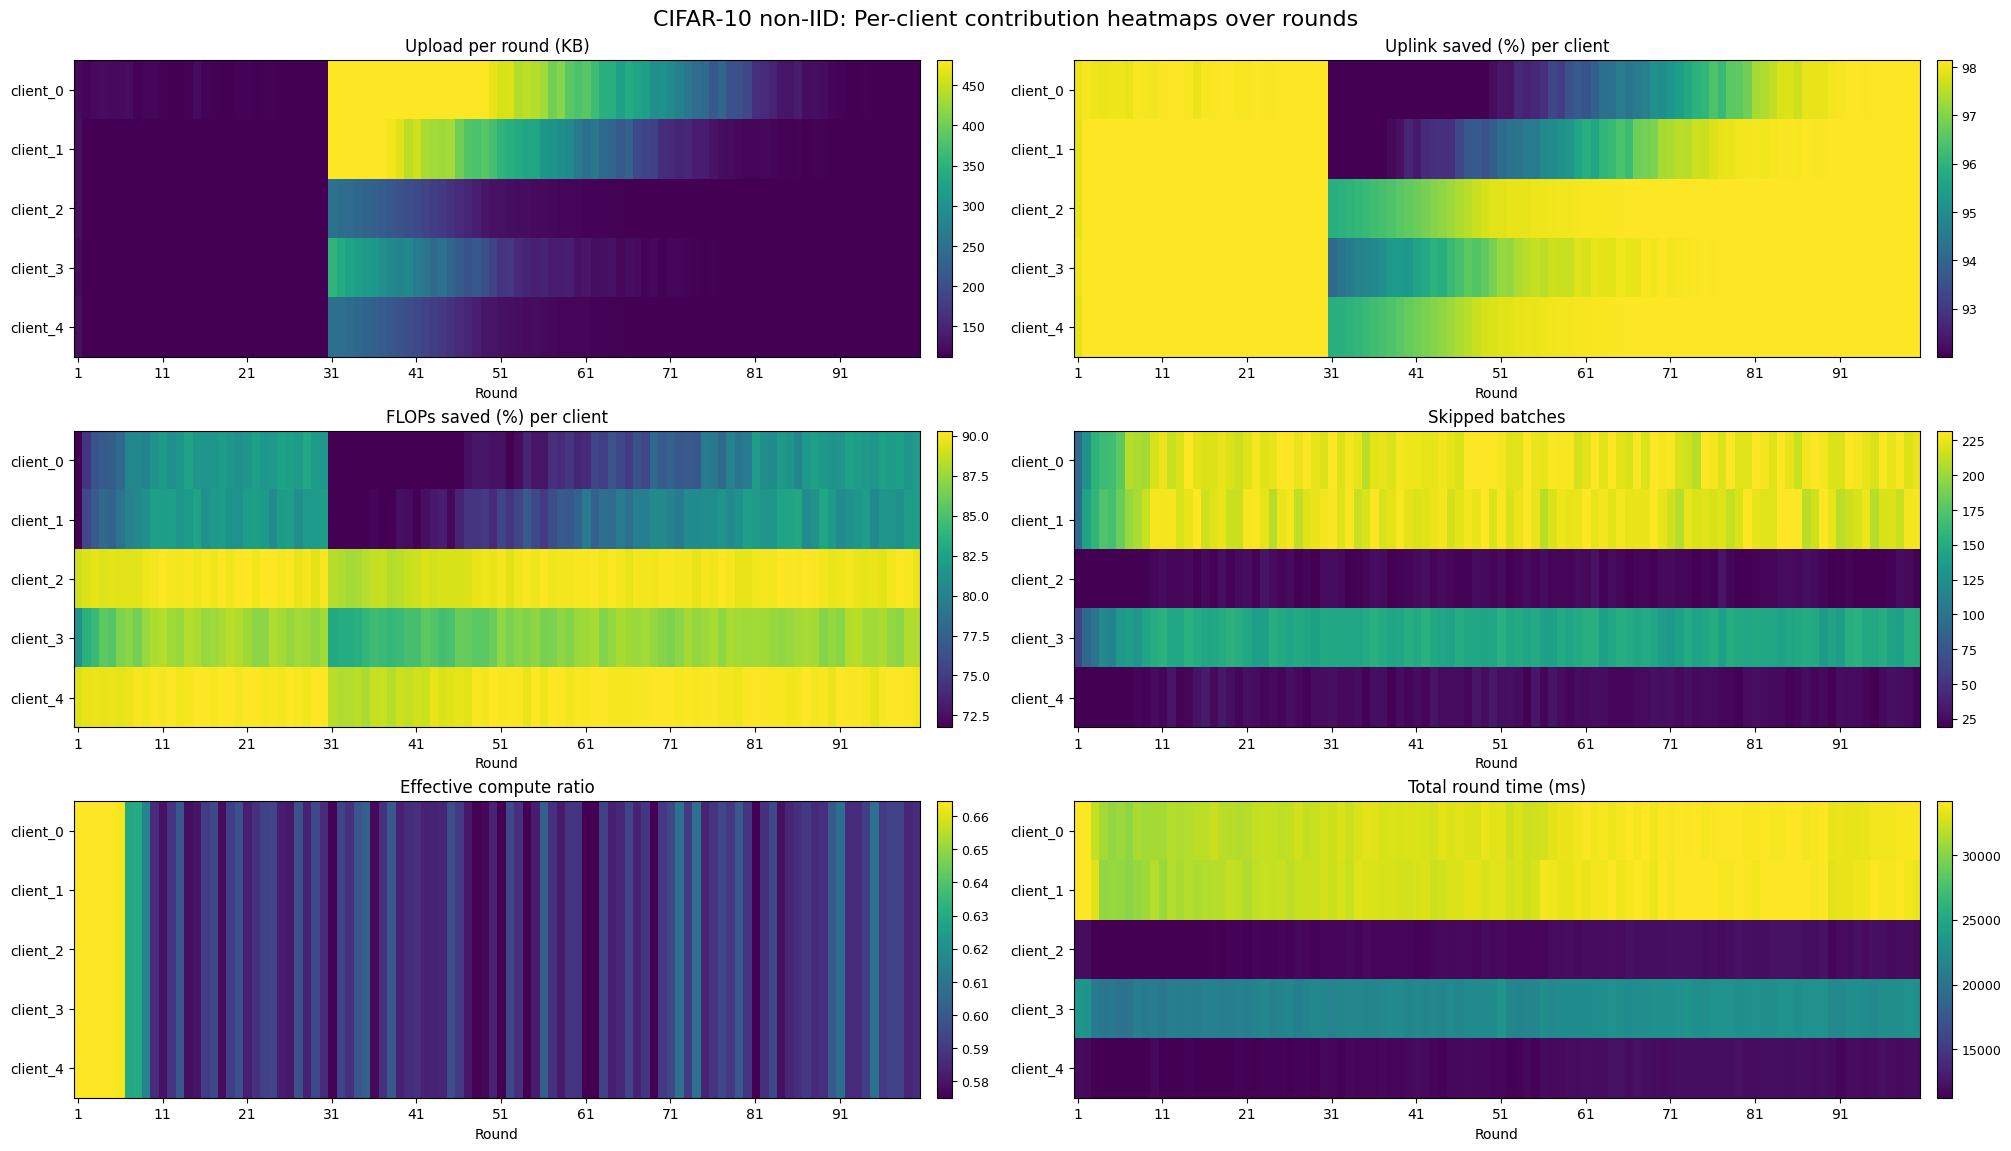

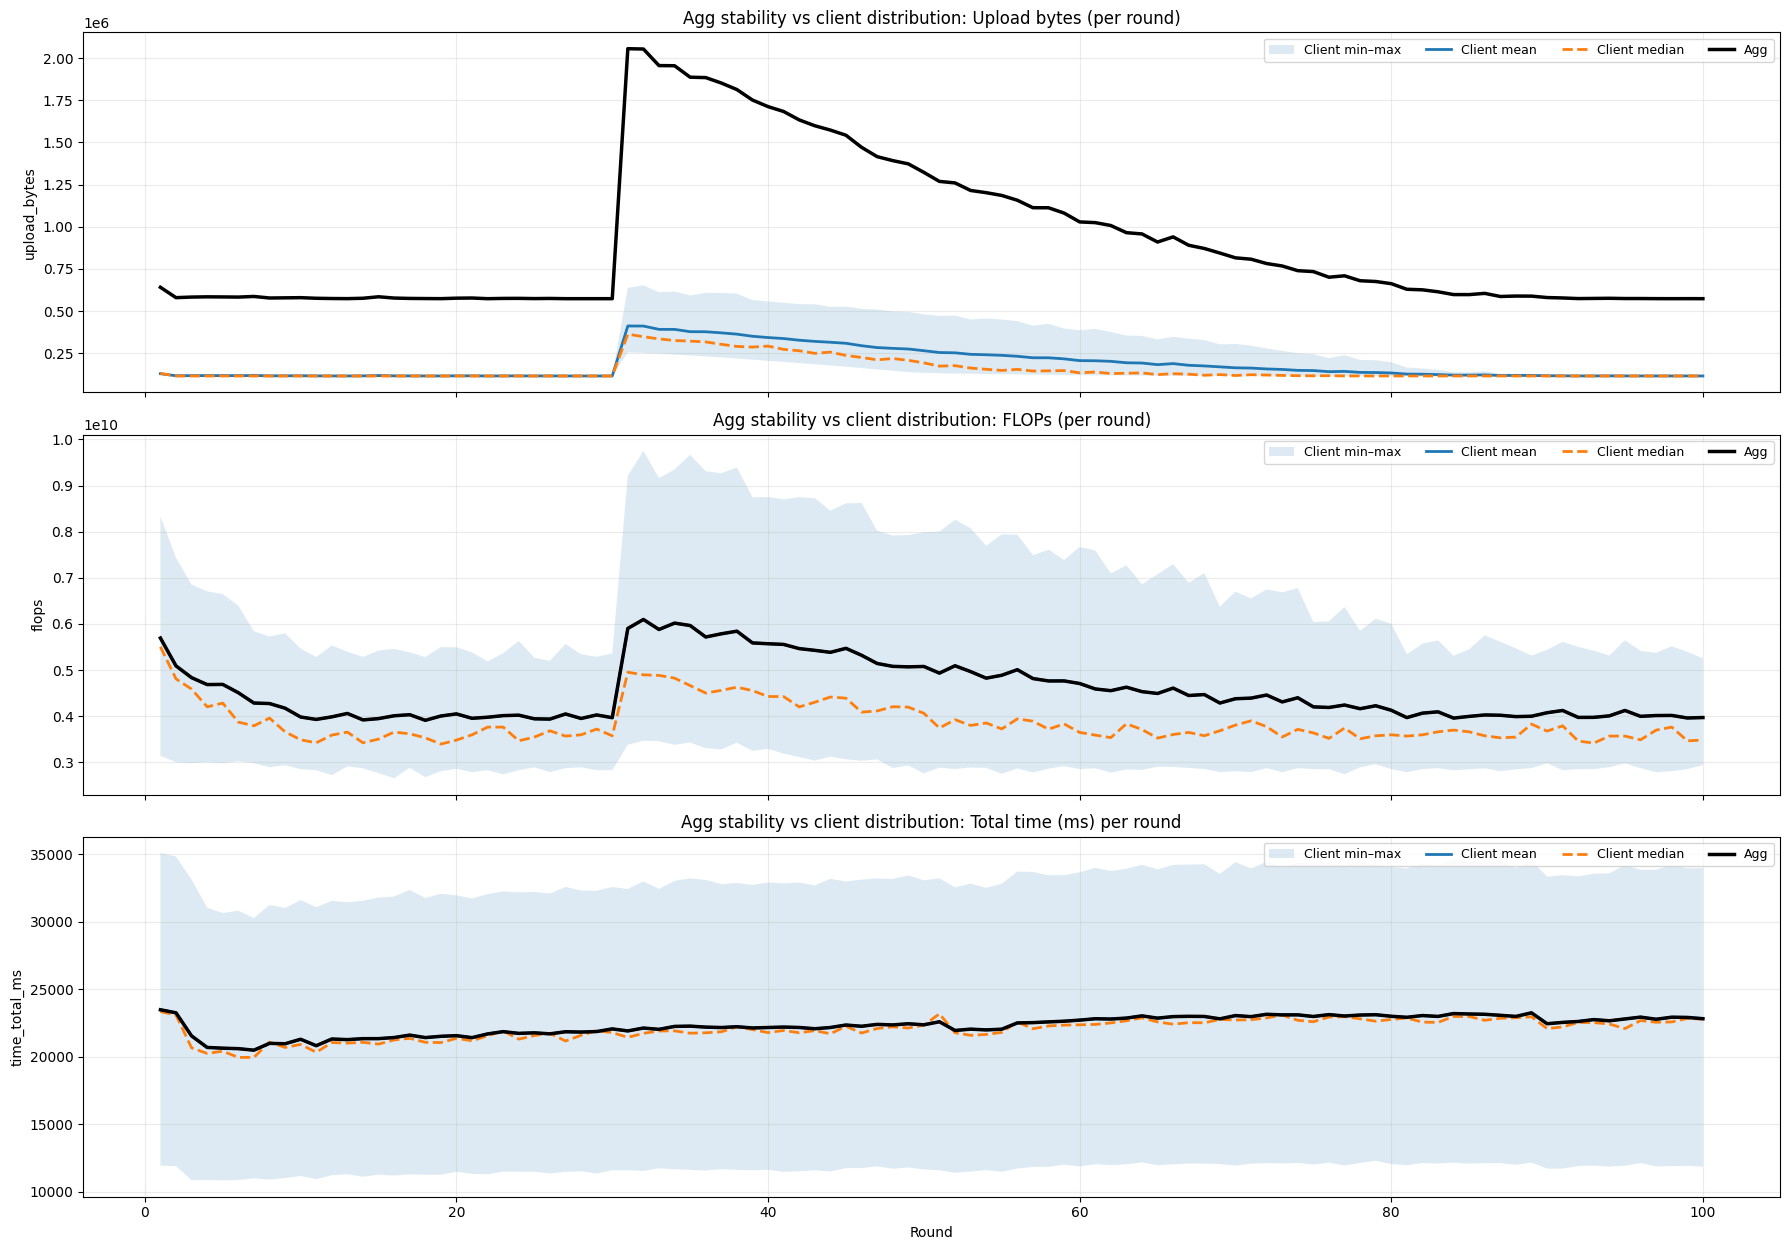

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

csv_path = r"ablations/noniid/full_perclient.csv"
df = pd.read_csv(csv_path)

df["round"] = pd.to_numeric(df["round"], errors="coerce")
df = df.dropna(subset=["round"])

# Split clients vs agg
df_clients = df[df["client_id"] != "agg"].copy()
df_agg = df[df["client_id"] == "agg"].copy()

df_clients = df_clients.sort_values(["client_id", "round"])
df_agg = df_agg.sort_values(["round"])

# ---- Per-client recomputed "savings" / contribution metrics (avoid accuracy) ----
# Compute saved % based on client raw values (varies across clients)
df_clients["uplink_saved_pct"] = 100.0 * (1.0 - df_clients["upload_bytes"] / df_clients["dense_upload_bytes_ref"])
df_clients["flops_saved_pct"]  = 100.0 * (1.0 - df_clients["flops"] / df_clients["dense_flops_ref"])

# Other per-client variable metrics (already in CSV)
# - skipped_batches: contribution intensity proxy (more skipping => less compute contribution)
# - time_total_ms: runtime burden
# - sparsity: how sparse each client is
# - effective_compute_ratio: compute intensity proxy
# - upload_bytes: raw comm contribution
# - time_topk_ms: overhead burden proxy
# - time_backward_ms: main compute proxy
df_clients["upload_kb"] = df_clients["upload_bytes"] / 1024.0

# Choose what to visualize
heatmap_metrics = [
    ("upload_kb", "Upload per round (KB)"),
    ("uplink_saved_pct", "Uplink saved (%) per client"),
    ("flops_saved_pct", "FLOPs saved (%) per client"),
    ("skipped_batches", "Skipped batches"),
    ("effective_compute_ratio", "Effective compute ratio"),
    ("time_total_ms", "Total round time (ms)"),
]

# Consistent ordering
clients = sorted(df_clients["client_id"].unique())
rounds = np.sort(df_clients["round"].unique())

def pivot_metric(col):
    piv = df_clients.pivot_table(index="client_id", columns="round", values=col, aggfunc="mean")
    piv = piv.reindex(index=clients, columns=rounds)
    return piv

# --------- Figure 1: Heatmaps (client x round) ----------
n = len(heatmap_metrics)
ncols = 2
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(20, 3.8 * nrows), constrained_layout=True)
axes = np.array(axes).reshape(nrows, ncols)

for i, (col, title) in enumerate(heatmap_metrics):
    ax = axes[i // ncols, i % ncols]
    mat = pivot_metric(col).values  # rows=clients, cols=rounds

    # robust color scaling to avoid one extreme dominating
    vmin = np.nanpercentile(mat, 5)
    vmax = np.nanpercentile(mat, 95)

    im = ax.imshow(mat, aspect="auto", interpolation="nearest", vmin=vmin, vmax=vmax, cmap="viridis")
    ax.set_title(title)
    ax.set_yticks(np.arange(len(clients)))
    ax.set_yticklabels(clients)

    # show fewer x ticks to keep it readable
    tick_step = 10
    tick_positions = np.arange(0, len(rounds), tick_step)
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(rounds[tick_positions].astype(int))
    ax.set_xlabel("Round")

    cbar = fig.colorbar(im, ax=ax, fraction=0.02, pad=0.02)
    cbar.ax.tick_params(labelsize=9)

# Hide unused subplots if any
for j in range(n, nrows * ncols):
    axes[j // ncols, j % ncols].axis("off")

fig.suptitle("CIFAR-10 non-IID: Per-client contribution heatmaps over rounds", fontsize=16)
plt.show()

# --------- Figure 2: "Agg not hurt" stability plot ----------
# Compare agg vs distribution of clients per round (mean/median + min/max band)
# Pick 2-3 metrics that represent contribution + cost.
stability_metrics = [
    ("upload_bytes", "Upload bytes (per round)", "upload_bytes"),
    ("flops", "FLOPs (per round)", "flops"),
    ("time_total_ms", "Total time (ms) per round", "time_total_ms"),
]

fig, axes = plt.subplots(len(stability_metrics), 1, figsize=(18, 4.2 * len(stability_metrics)), sharex=True)
if len(stability_metrics) == 1:
    axes = [axes]

for ax, (col, title, agg_col) in zip(axes, stability_metrics):
    per_round = df_clients.groupby("round")[col].agg(["mean", "median", "min", "max"]).reset_index()
    ax.fill_between(per_round["round"], per_round["min"], per_round["max"], alpha=0.15, label="Client min–max")
    ax.plot(per_round["round"], per_round["mean"], linewidth=2.0, label="Client mean")
    ax.plot(per_round["round"], per_round["median"], linewidth=2.0, linestyle="--", label="Client median")

    # Agg curve (from agg rows)
    if agg_col in df_agg.columns:
        ax.plot(df_agg["round"], df_agg[agg_col], color="black", linewidth=2.5, label="Agg")

    ax.set_title(f"Agg stability vs client distribution: {title}")
    ax.set_ylabel(col)
    ax.grid(True, alpha=0.25)
    ax.legend(ncol=4, fontsize=9, frameon=True, loc="upper right")

axes[-1].set_xlabel("Round")
plt.tight_layout()
plt.show()

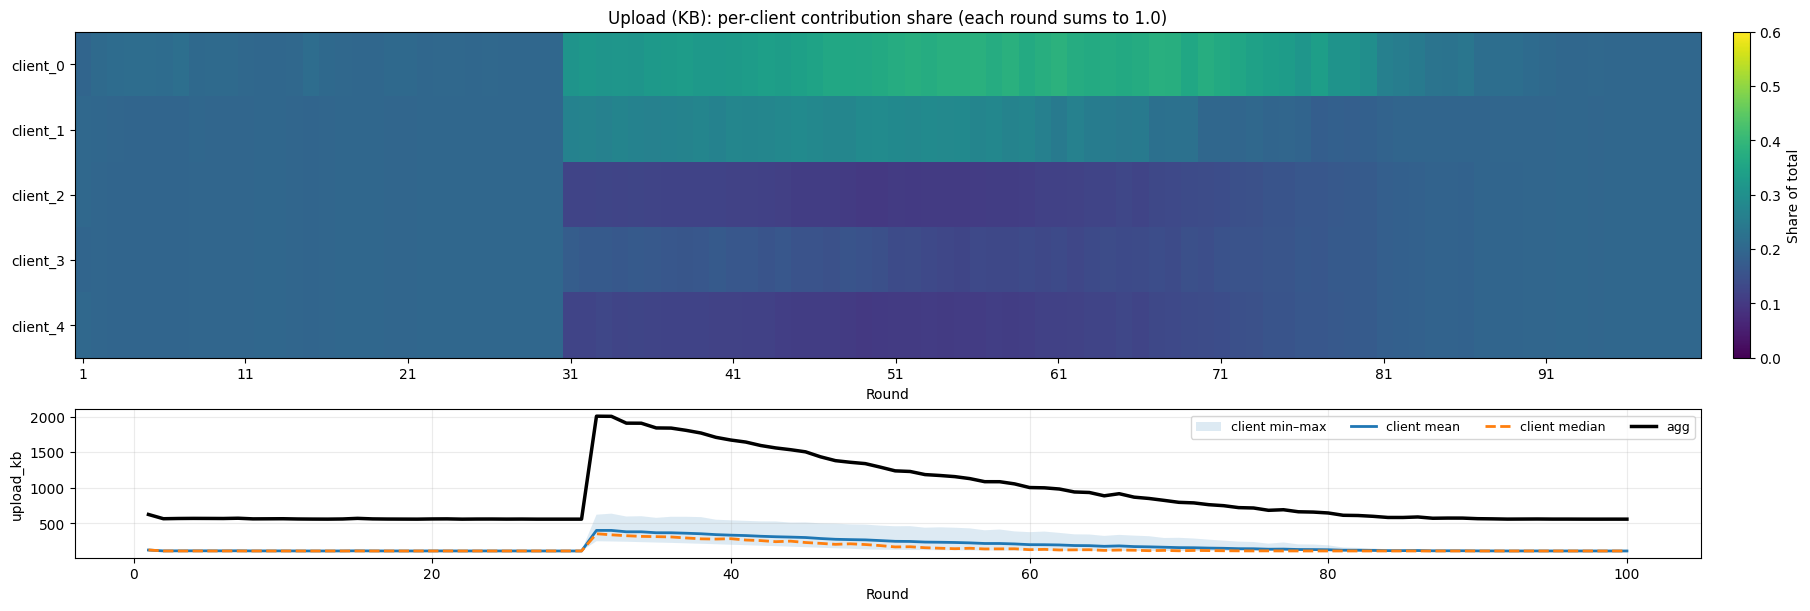

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

csv_path = r"ablations/noniid/full_perclient.csv"
df = pd.read_csv(csv_path)
df["round"] = pd.to_numeric(df["round"], errors="coerce")
df = df.dropna(subset=["round"])

clients_df = df[df["client_id"] != "agg"].copy()
agg_df = df[df["client_id"] == "agg"].copy()

clients = sorted(clients_df["client_id"].unique())
rounds = np.sort(clients_df["round"].unique())

def contribution_share_heatmap(value_col, title, vmin=0, vmax=1):
    piv = clients_df.pivot_table(index="client_id", columns="round", values=value_col, aggfunc="mean")
    piv = piv.reindex(index=clients, columns=rounds)

    # per-round share (column-normalize)
    share = piv.div(piv.sum(axis=0), axis=1)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 6), gridspec_kw={"height_ratios":[2.2, 1]}, constrained_layout=True)

    im = ax1.imshow(share.values, aspect="auto", interpolation="nearest", cmap="viridis", vmin=vmin, vmax=vmax)
    ax1.set_title(f"{title}: per-client contribution share (each round sums to 1.0)")
    ax1.set_yticks(np.arange(len(clients)))
    ax1.set_yticklabels(clients)

    tick_step = 10
    tick_pos = np.arange(0, len(rounds), tick_step)
    ax1.set_xticks(tick_pos)
    ax1.set_xticklabels(rounds[tick_pos].astype(int))
    ax1.set_xlabel("Round")
    cbar = fig.colorbar(im, ax=ax1, fraction=0.02, pad=0.02)
    cbar.set_label("Share of total")

    # "agg not hurt" style: show total + client spread
    pr = clients_df.groupby("round")[value_col].agg(["mean","median","min","max"]).reset_index()
    ax2.fill_between(pr["round"], pr["min"], pr["max"], alpha=0.15, label="client min–max")
    ax2.plot(pr["round"], pr["mean"], linewidth=2, label="client mean")
    ax2.plot(pr["round"], pr["median"], linewidth=2, linestyle="--", label="client median")
    if value_col in agg_df.columns:
        ax2.plot(agg_df["round"], agg_df[value_col], color="black", linewidth=2.5, label="agg")
    ax2.set_ylabel(value_col)
    ax2.grid(True, alpha=0.25)
    ax2.legend(ncol=4, fontsize=9, frameon=True, loc="upper right")
    ax2.set_xlabel("Round")

    plt.show()

# 1) Communication contribution (most interpretable)
clients_df["upload_kb"] = clients_df["upload_bytes"] / 1024.0
agg_df["upload_kb"] = agg_df["upload_bytes"] / 1024.0
contribution_share_heatmap("upload_kb", "Upload (KB)", vmin=0.0, vmax=0.6)

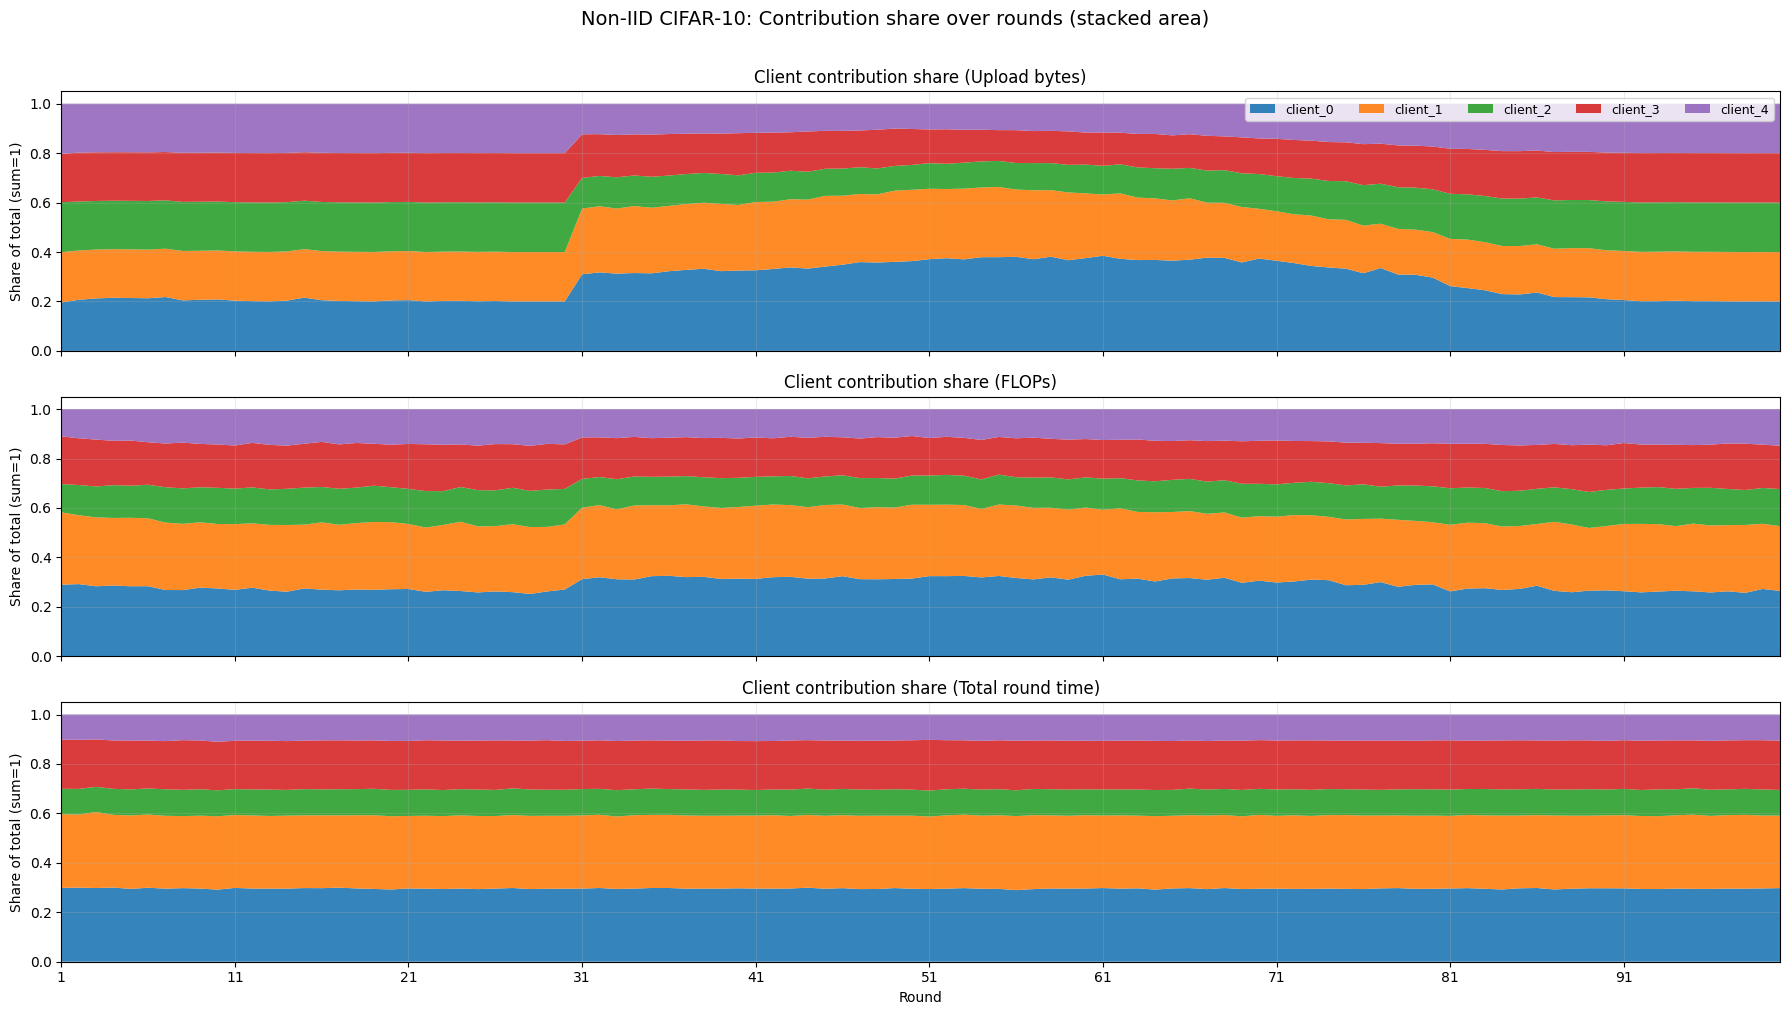

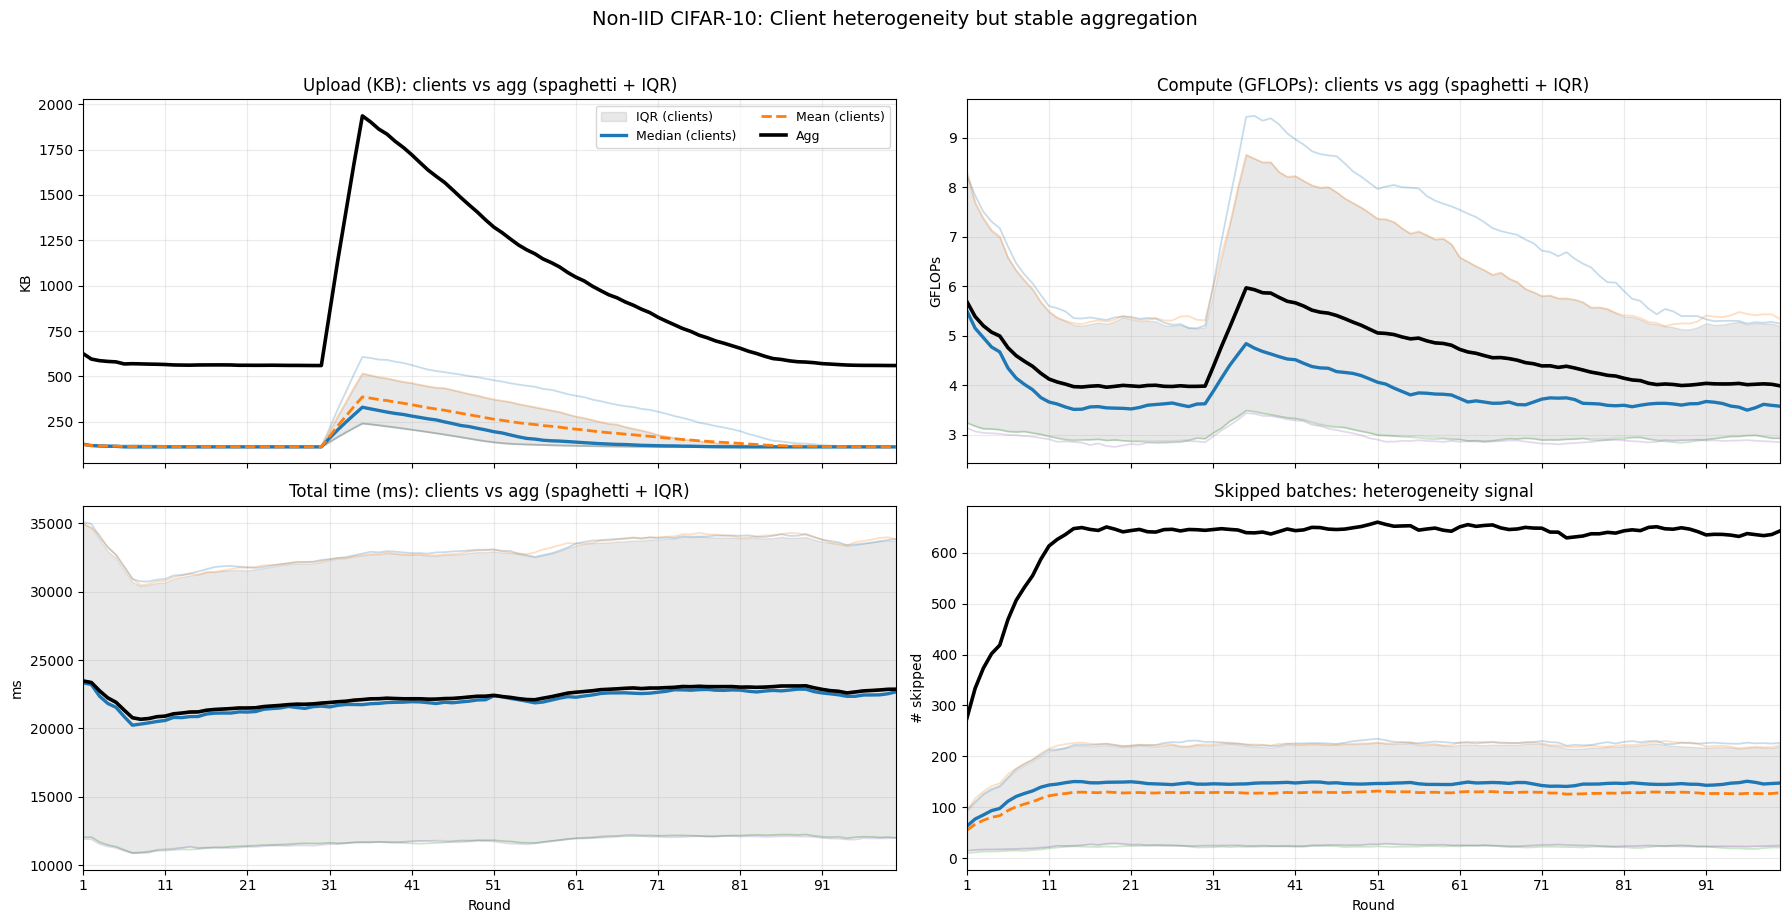

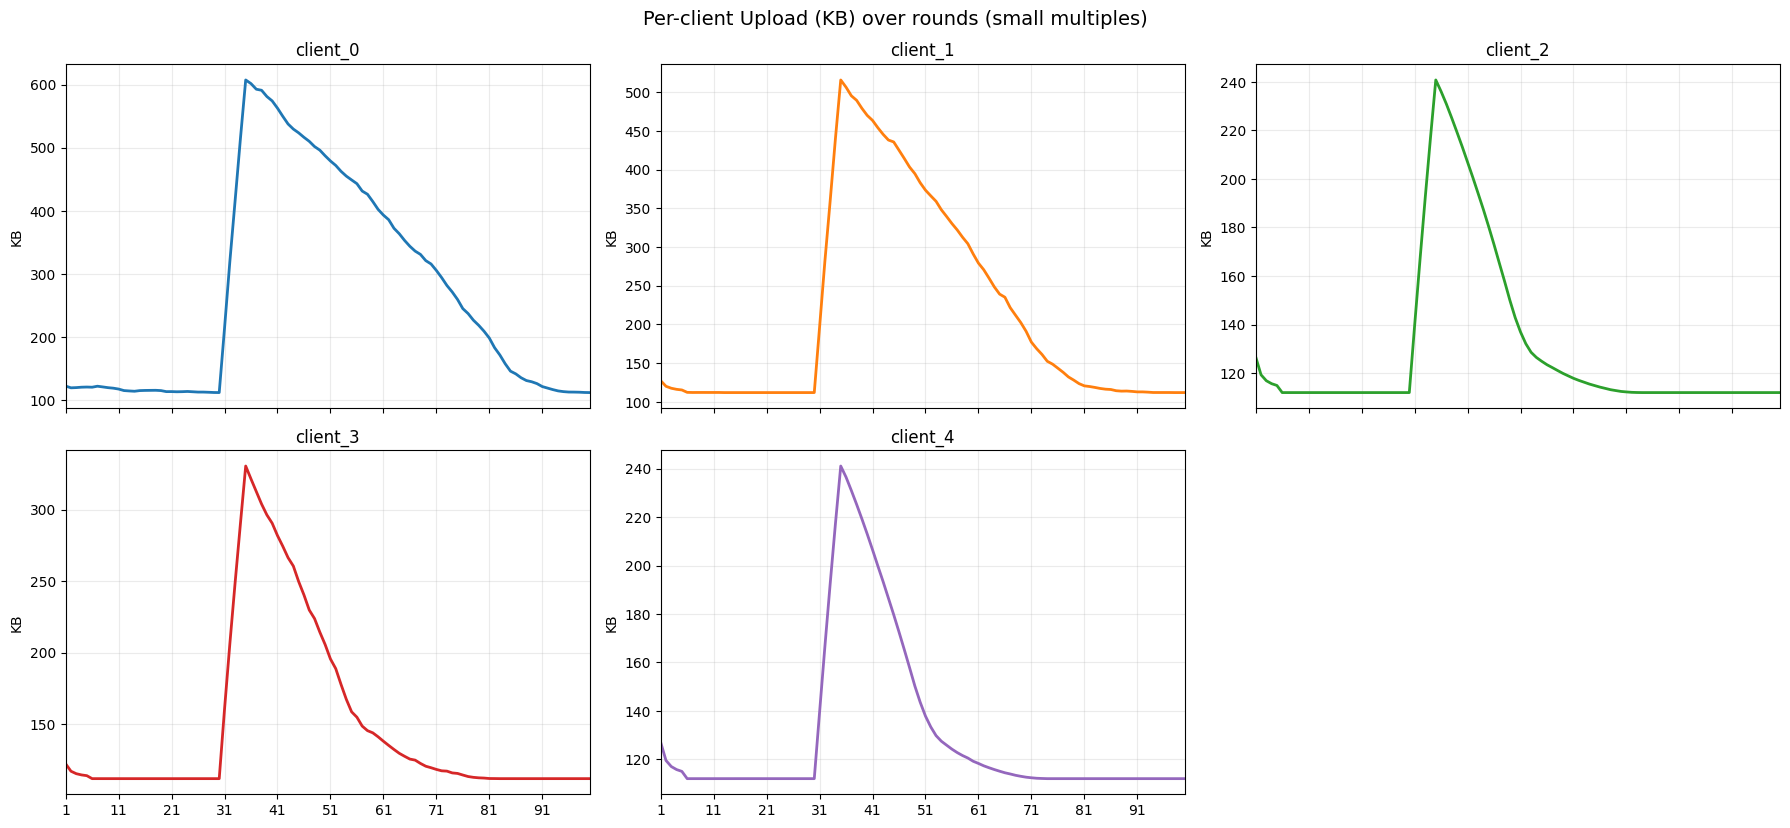

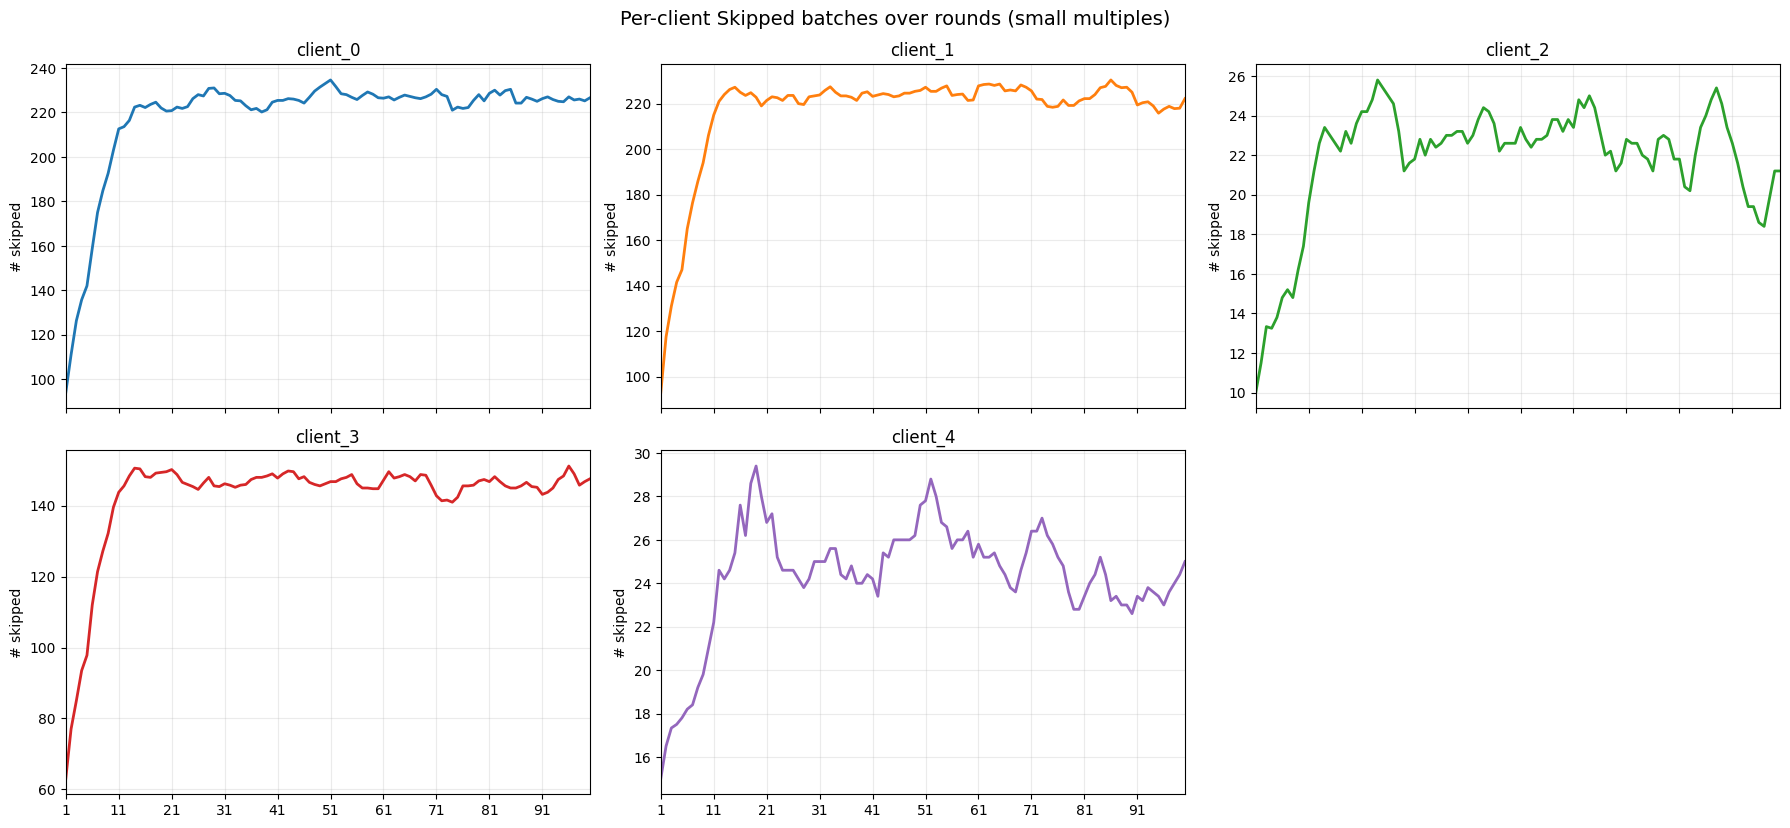

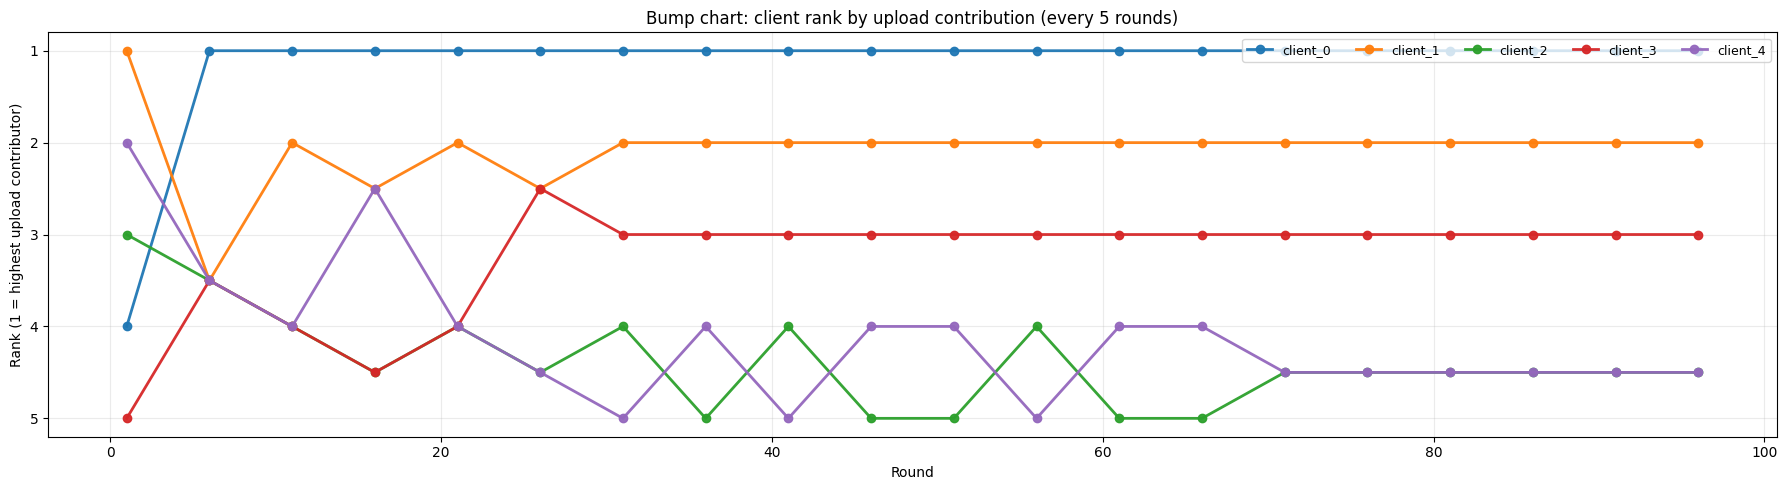

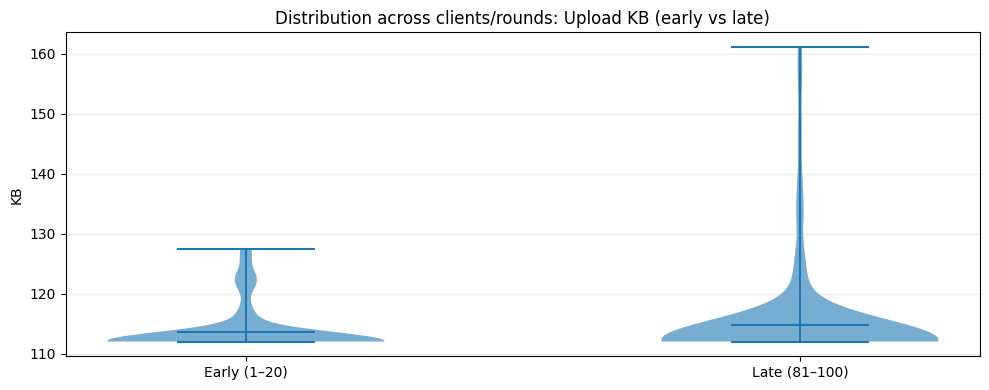

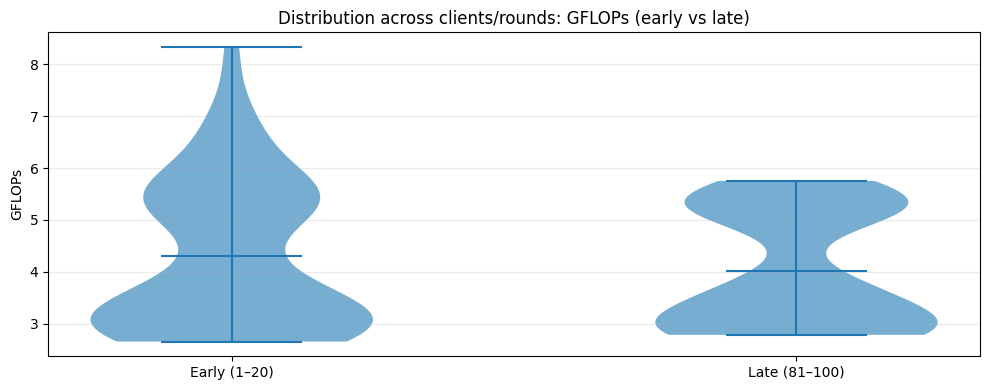

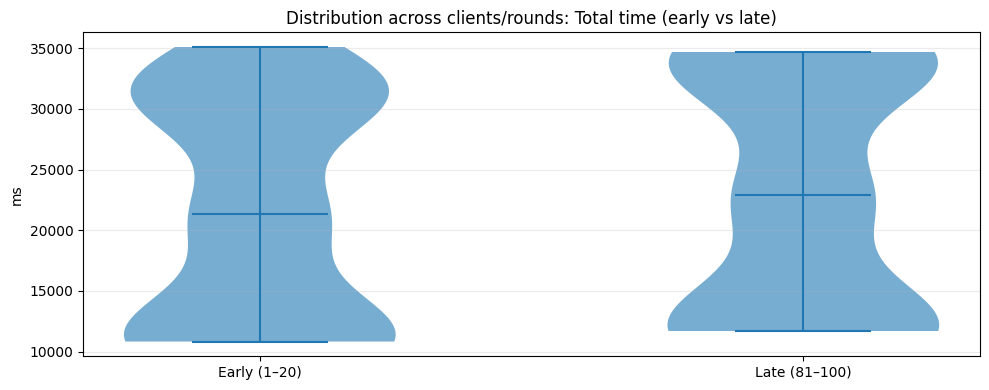

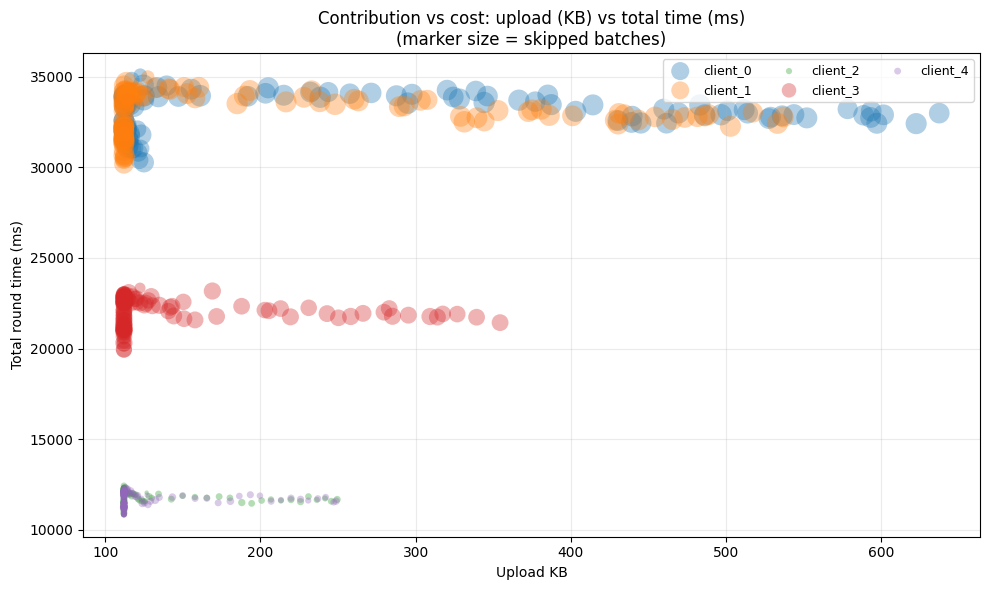

In [7]:
# Paper-style alternatives (NO heatmaps / NO boxplots) for:
# - per-client contribution over rounds
# - showing aggregation (agg) stays stable under non-IID
#
# This cell generates ALL of:
# 1) Stacked area "contribution share" (upload, FLOPs, time)
# 2) Spaghetti + IQR band + (optional) agg overlay (upload, FLOPs, time, skipped)
# 3) Small multiples (one subplot per client) for 2 key metrics
# 4) Bump chart (rank of clients by contribution over rounds)
# 5) Early vs late distribution comparison (violin) across clients
# 6) Scatter "contribution vs cost" (upload vs time) with size=skipping

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --------------------
# Load
# --------------------
csv_path = r"ablations/noniid/full_perclient.csv"
df = pd.read_csv(csv_path)
df["round"] = pd.to_numeric(df["round"], errors="coerce")
df = df.dropna(subset=["round"])

df_clients = df[df["client_id"] != "agg"].copy()
df_agg = df[df["client_id"] == "agg"].copy()

df_clients = df_clients.sort_values(["client_id", "round"])
df_agg = df_agg.sort_values(["round"])

clients = sorted(df_clients["client_id"].unique())
rounds = np.sort(df_clients["round"].unique())

# Derived columns (avoid accuracy)
df_clients["upload_kb"] = df_clients["upload_bytes"] / 1024.0
df_clients["gflops"] = df_clients["flops"] / 1e9

# recomputed per-client savings (if you want them later)
df_clients["uplink_saved_pct_client"] = 100.0 * (1.0 - df_clients["upload_bytes"] / df_clients["dense_upload_bytes_ref"])
df_clients["flops_saved_pct_client"]  = 100.0 * (1.0 - df_clients["flops"] / df_clients["dense_flops_ref"])

# Also compute same derived for agg for overlay plots
if len(df_agg) > 0:
    df_agg["upload_kb"] = df_agg["upload_bytes"] / 1024.0
    df_agg["gflops"] = df_agg["flops"] / 1e9

# Plot controls
tick_step = 10
smooth_window = 5  # set to 1 for no smoothing
rng = np.random.default_rng(0)

# Consistent client colors
cmap = plt.cm.tab10(np.linspace(0, 1, max(10, len(clients))))
client_color = {cid: cmap[i] for i, cid in enumerate(clients)}

def set_round_ticks(ax):
    ax.set_xticks(np.arange(rounds.min(), rounds.max() + 1, tick_step))
    ax.set_xlim(rounds.min(), rounds.max())
    ax.grid(True, alpha=0.25)

def pivot_clients(value_col):
    piv = df_clients.pivot_table(index="client_id", columns="round", values=value_col, aggfunc="mean")
    return piv.reindex(index=clients, columns=rounds)

def rolling(s, w):
    if w is None or w <= 1:
        return s
    return s.rolling(w, min_periods=1).mean()

# ============================================================
# 1) Stacked area: per-round contribution share (paper-friendly)
# ============================================================
def stacked_share_plot(value_col, title, ax):
    piv = pivot_clients(value_col)
    total = piv.sum(axis=0)
    share = piv.div(total, axis=1)  # each column sums to ~1

    x = share.columns.values
    ys = [share.loc[c].values for c in clients]
    colors = [client_color[c] for c in clients]

    ax.stackplot(x, ys, labels=clients, colors=colors, alpha=0.9)
    ax.set_title(title)
    ax.set_ylabel("Share of total (sum=1)")
    set_round_ticks(ax)

fig, axes = plt.subplots(3, 1, figsize=(18, 10), sharex=True)
stacked_share_plot("upload_bytes", "Client contribution share (Upload bytes)", axes[0])
stacked_share_plot("flops", "Client contribution share (FLOPs)", axes[1])
stacked_share_plot("time_total_ms", "Client contribution share (Total round time)", axes[2])
axes[-1].set_xlabel("Round")
axes[0].legend(ncol=5, fontsize=9, frameon=True, loc="upper right")
plt.suptitle("Non-IID CIFAR-10: Contribution share over rounds (stacked area)", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

# ============================================================
# 2) Spaghetti + IQR band + agg overlay (stability under non-IID)
# ============================================================
def spaghetti_iqr(value_col, title, ax, ylabel=None):
    # per-client lines (light)
    for cid in clients:
        sub = df_clients[df_clients["client_id"] == cid].sort_values("round")
        ax.plot(sub["round"], rolling(sub[value_col], smooth_window),
                color=client_color[cid], alpha=0.25, linewidth=1.3)

    # per-round summary across clients
    pr = df_clients.groupby("round")[value_col].agg(q25=lambda x: np.quantile(x, 0.25),
                                                   q50=lambda x: np.quantile(x, 0.50),
                                                   q75=lambda x: np.quantile(x, 0.75),
                                                   mean="mean").reset_index()
    pr = pr.sort_values("round")
    # smooth summaries
    pr["q25"] = rolling(pr["q25"], smooth_window)
    pr["q50"] = rolling(pr["q50"], smooth_window)
    pr["q75"] = rolling(pr["q75"], smooth_window)
    pr["mean"] = rolling(pr["mean"], smooth_window)

    ax.fill_between(pr["round"], pr["q25"], pr["q75"], alpha=0.18, color="gray", label="IQR (clients)")
    ax.plot(pr["round"], pr["q50"], color="tab:blue", linewidth=2.4, label="Median (clients)")
    ax.plot(pr["round"], pr["mean"], color="tab:orange", linewidth=2.0, linestyle="--", label="Mean (clients)")

    # agg overlay if available
    if len(df_agg) > 0 and value_col in df_agg.columns:
        ax.plot(df_agg["round"], rolling(df_agg[value_col], smooth_window),
                color="black", linewidth=2.6, label="Agg")

    ax.set_title(title)
    if ylabel:
        ax.set_ylabel(ylabel)
    set_round_ticks(ax)

fig, axes = plt.subplots(2, 2, figsize=(18, 9), sharex=True)
spaghetti_iqr("upload_kb", "Upload (KB): clients vs agg (spaghetti + IQR)", axes[0,0], ylabel="KB")
spaghetti_iqr("gflops", "Compute (GFLOPs): clients vs agg (spaghetti + IQR)", axes[0,1], ylabel="GFLOPs")
spaghetti_iqr("time_total_ms", "Total time (ms): clients vs agg (spaghetti + IQR)", axes[1,0], ylabel="ms")
spaghetti_iqr("skipped_batches", "Skipped batches: heterogeneity signal", axes[1,1], ylabel="# skipped")
axes[1,0].set_xlabel("Round")
axes[1,1].set_xlabel("Round")
axes[0,0].legend(ncol=2, fontsize=9, frameon=True, loc="upper right")
plt.suptitle("Non-IID CIFAR-10: Client heterogeneity but stable aggregation", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

# ============================================================
# 3) Small multiples (one subplot per client) - very readable
# ============================================================
def small_multiples(metric, title, ylabel):
    n = len(clients)
    ncols = 3
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4.2 * nrows), sharex=True)
    axes = np.array(axes).reshape(nrows, ncols)

    for i, cid in enumerate(clients):
        ax = axes[i // ncols, i % ncols]
        sub = df_clients[df_clients["client_id"] == cid].sort_values("round")
        ax.plot(sub["round"], rolling(sub[metric], smooth_window),
                color=client_color[cid], linewidth=2.0)
        ax.set_title(cid)
        ax.set_ylabel(ylabel)
        set_round_ticks(ax)

    for j in range(n, nrows * ncols):
        axes[j // ncols, j % ncols].axis("off")

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

small_multiples("upload_kb", "Per-client Upload (KB) over rounds (small multiples)", "KB")
small_multiples("skipped_batches", "Per-client Skipped batches over rounds (small multiples)", "# skipped")

# ============================================================
# 4) Bump chart: ranking of clients by contribution (upload share)
# ============================================================
# Downsample rounds for readability
bump_step = 5
bump_rounds = rounds[::bump_step]

piv_upload = pivot_clients("upload_bytes").loc[:, bump_rounds]
share_upload = piv_upload.div(piv_upload.sum(axis=0), axis=1)

# rank per round (1 = highest contributor)
ranks = share_upload.rank(axis=0, ascending=False, method="average")

plt.figure(figsize=(18, 5))
for cid in clients:
    plt.plot(bump_rounds, ranks.loc[cid].values, marker="o", linewidth=2.0,
             color=client_color[cid], label=cid, alpha=0.95)

plt.gca().invert_yaxis()
plt.yticks(range(1, len(clients) + 1))
plt.title(f"Bump chart: client rank by upload contribution (every {bump_step} rounds)")
plt.xlabel("Round")
plt.ylabel("Rank (1 = highest upload contributor)")
plt.grid(True, alpha=0.25)
plt.legend(ncol=5, fontsize=9, frameon=True, loc="upper right")
plt.tight_layout()
plt.show()

# ============================================================
# 5) Early vs late distributions across clients (violin)
# ============================================================
early = df_clients[df_clients["round"].between(1, 20)]
late  = df_clients[df_clients["round"].between(81, 100)]

def violin_early_late(metric, title, ylabel):
    data = [early[metric].dropna().values, late[metric].dropna().values]
    plt.figure(figsize=(10, 4))
    parts = plt.violinplot(data, showmeans=True, showextrema=True)
    for pc in parts["bodies"]:
        pc.set_alpha(0.6)
    plt.xticks([1, 2], ["Early (1–20)", "Late (81–100)"])
    plt.title(title)
    plt.ylabel(ylabel)
    plt.grid(True, alpha=0.25, axis="y")
    plt.tight_layout()
    plt.show()

violin_early_late("upload_kb", "Distribution across clients/rounds: Upload KB (early vs late)", "KB")
violin_early_late("gflops", "Distribution across clients/rounds: GFLOPs (early vs late)", "GFLOPs")
violin_early_late("time_total_ms", "Distribution across clients/rounds: Total time (early vs late)", "ms")

# ============================================================
# 6) Scatter: contribution vs cost (paper-style diagnostic)
#    x=upload_kb, y=time_total_ms, size=skipped_batches, color=client
# ============================================================
# Sample points to avoid clutter (optional)
sample_df = df_clients.copy()
# sample_df = df_clients[df_clients["round"] % 2 == 0].copy()  # uncomment to downsample

plt.figure(figsize=(10, 6))
for cid in clients:
    sub = sample_df[sample_df["client_id"] == cid]
    plt.scatter(sub["upload_kb"], sub["time_total_ms"],
                s=np.clip(sub["skipped_batches"], 5, 250),  # size encodes skipping
                alpha=0.35, color=client_color[cid], label=cid, edgecolors="none")

plt.title("Contribution vs cost: upload (KB) vs total time (ms)\n(marker size = skipped batches)")
plt.xlabel("Upload KB")
plt.ylabel("Total round time (ms)")
plt.grid(True, alpha=0.25)
plt.legend(ncol=3, fontsize=9, frameon=True, loc="upper right")
plt.tight_layout()
plt.show()

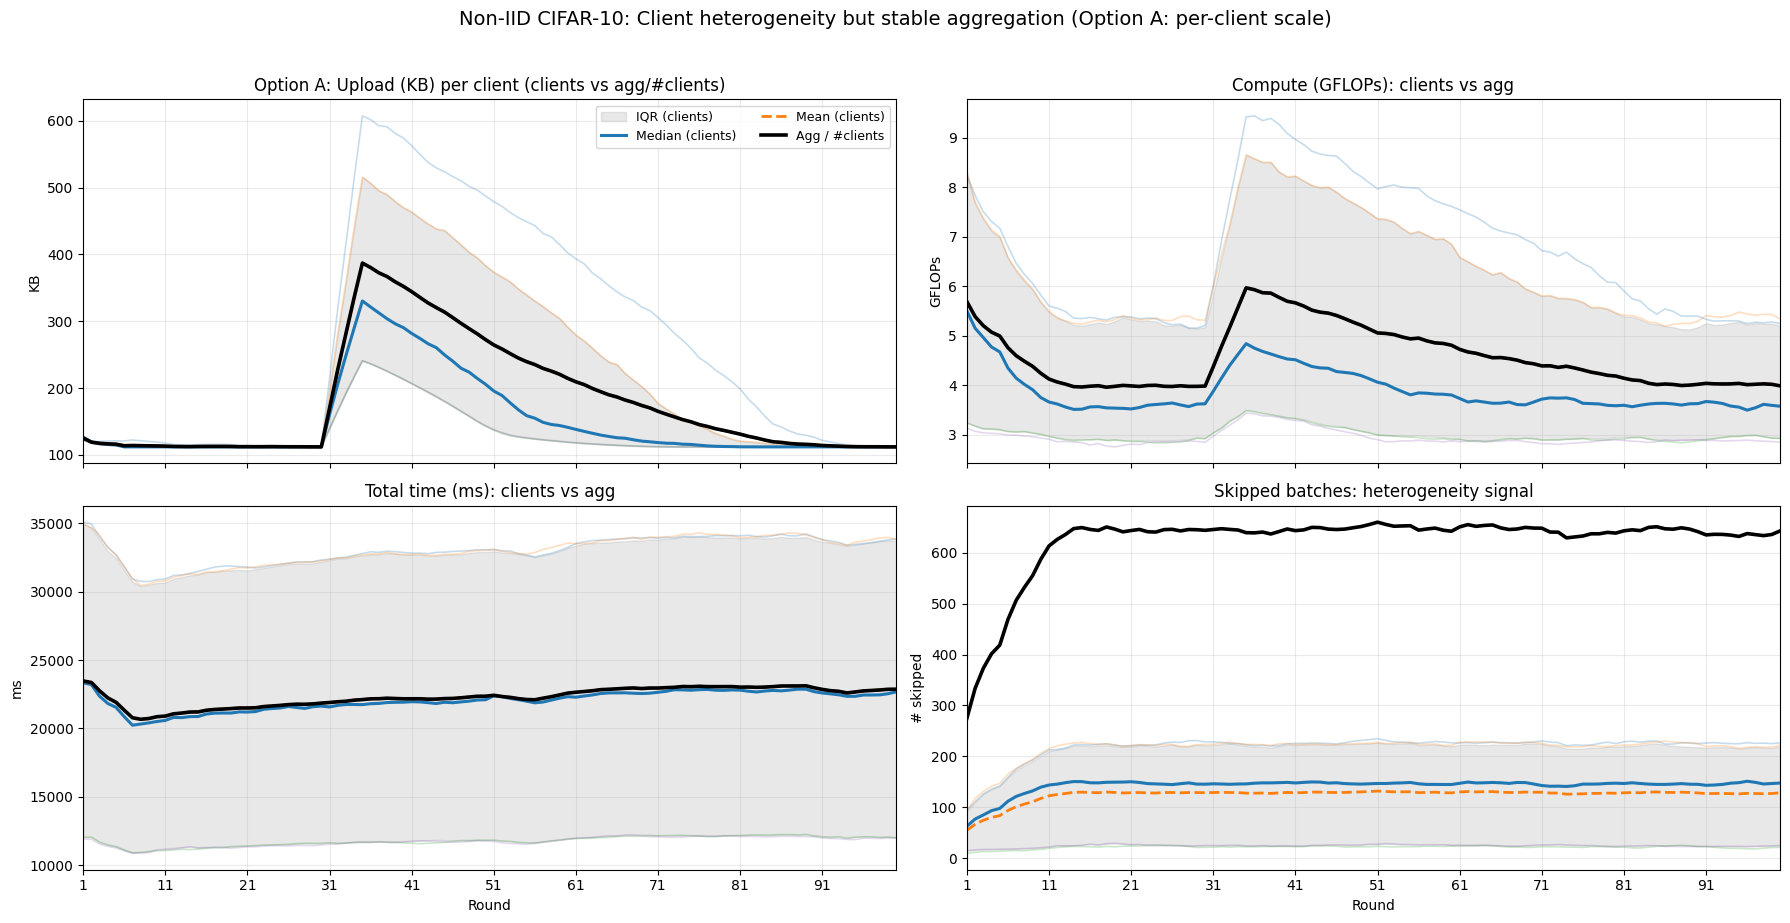

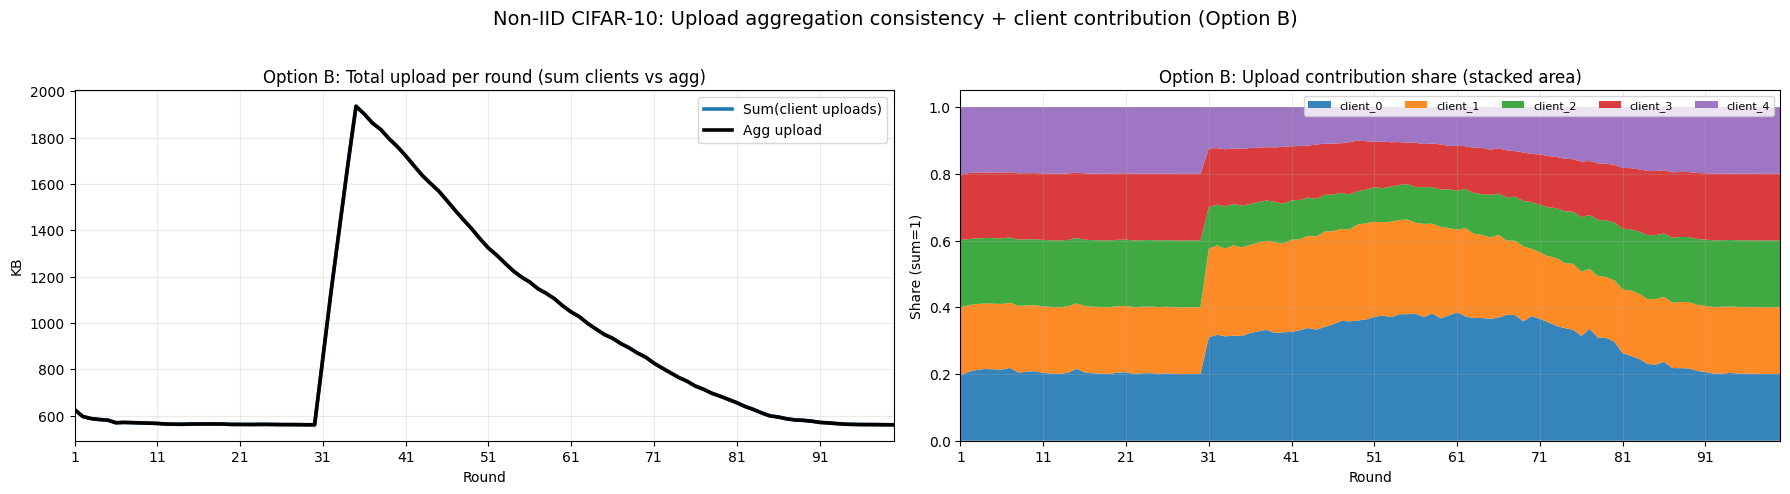

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

csv_path = r"ablations/noniid/full_perclient.csv"
df = pd.read_csv(csv_path)
df["round"] = pd.to_numeric(df["round"], errors="coerce")
df = df.dropna(subset=["round"])

df_clients = df[df["client_id"] != "agg"].copy()
df_agg = df[df["client_id"] == "agg"].copy()

df_clients = df_clients.sort_values(["client_id", "round"])
df_agg = df_agg.sort_values(["round"])

clients = sorted(df_clients["client_id"].unique())
rounds = np.sort(df_clients["round"].unique())
n_clients = len(clients)

# Derived
df_clients["upload_kb"] = df_clients["upload_bytes"] / 1024.0
df_clients["gflops"] = df_clients["flops"] / 1e9
if len(df_agg) > 0:
    df_agg["upload_kb"] = df_agg["upload_bytes"] / 1024.0
    df_agg["gflops"] = df_agg["flops"] / 1e9

# Plot style
tick_step = 10
smooth_window = 5  # set 1 for no smoothing

cmap = plt.cm.tab10(np.linspace(0, 1, max(10, len(clients))))
client_color = {cid: cmap[i] for i, cid in enumerate(clients)}

def rolling(s, w):
    if w is None or w <= 1:
        return s
    return s.rolling(w, min_periods=1).mean()

def set_round_ticks(ax):
    ax.set_xticks(np.arange(rounds.min(), rounds.max() + 1, tick_step))
    ax.set_xlim(rounds.min(), rounds.max())
    ax.grid(True, alpha=0.25)

def spaghetti_iqr(ax, value_col, title, ylabel=None, agg_series=None):
    # per-client faint lines
    for cid in clients:
        sub = df_clients[df_clients["client_id"] == cid].sort_values("round")
        ax.plot(sub["round"], rolling(sub[value_col], smooth_window),
                color=client_color[cid], alpha=0.25, linewidth=1.2)

    # per-round summary across clients
    pr = df_clients.groupby("round")[value_col].agg(
        q25=lambda x: np.quantile(x, 0.25),
        q50=lambda x: np.quantile(x, 0.50),
        q75=lambda x: np.quantile(x, 0.75),
        mean="mean",
    ).reset_index().sort_values("round")

    pr["q25"] = rolling(pr["q25"], smooth_window)
    pr["q50"] = rolling(pr["q50"], smooth_window)
    pr["q75"] = rolling(pr["q75"], smooth_window)
    pr["mean"] = rolling(pr["mean"], smooth_window)

    ax.fill_between(pr["round"], pr["q25"], pr["q75"], alpha=0.18, color="gray", label="IQR (clients)")
    ax.plot(pr["round"], pr["q50"], color="tab:blue", linewidth=2.2, label="Median (clients)")
    ax.plot(pr["round"], pr["mean"], color="tab:orange", linewidth=2.0, linestyle="--", label="Mean (clients)")

    if agg_series is not None:
        ax.plot(agg_series["round"], rolling(agg_series["value"], smooth_window),
                color="black", linewidth=2.6, label=agg_series["label"])

    ax.set_title(title)
    if ylabel:
        ax.set_ylabel(ylabel)
    set_round_ticks(ax)

# -----------------------------
# Option A: per-client scale (agg normalized per client)
# -----------------------------
agg_per_client = None
if len(df_agg) > 0:
    tmp = df_agg[["round", "upload_kb"]].copy()
    tmp["value"] = tmp["upload_kb"] / max(1, n_clients)
    agg_per_client = {"round": tmp["round"], "value": tmp["value"], "label": "Agg / #clients"}

fig, axes = plt.subplots(2, 2, figsize=(18, 9), sharex=True)
spaghetti_iqr(axes[0,0], "upload_kb", "Option A: Upload (KB) per client (clients vs agg/#clients)", ylabel="KB", agg_series=agg_per_client)
spaghetti_iqr(axes[0,1], "gflops", "Compute (GFLOPs): clients vs agg", ylabel="GFLOPs",
              agg_series={"round": df_agg["round"], "value": df_agg["gflops"], "label": "Agg"} if len(df_agg) else None)
spaghetti_iqr(axes[1,0], "time_total_ms", "Total time (ms): clients vs agg", ylabel="ms",
              agg_series={"round": df_agg["round"], "value": df_agg["time_total_ms"], "label": "Agg"} if len(df_agg) else None)
spaghetti_iqr(axes[1,1], "skipped_batches", "Skipped batches: heterogeneity signal", ylabel="# skipped",
              agg_series={"round": df_agg["round"], "value": df_agg["skipped_batches"], "label": "Agg"} if len(df_agg) else None)

axes[1,0].set_xlabel("Round"); axes[1,1].set_xlabel("Round")
axes[0,0].legend(ncol=2, fontsize=9, frameon=True, loc="upper right")
plt.suptitle("Non-IID CIFAR-10: Client heterogeneity but stable aggregation (Option A: per-client scale)", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

# -----------------------------
# Option B: total scale (client-sum vs agg)
# -----------------------------
# Build total upload across clients per round
upload_sum = df_clients.groupby("round")["upload_kb"].sum().reset_index()
upload_sum = upload_sum.sort_values("round")
upload_sum_series = {"round": upload_sum["round"], "value": upload_sum["upload_kb"], "label": "Sum over clients"}

agg_total_series = None
if len(df_agg) > 0:
    agg_total_series = {"round": df_agg["round"], "value": df_agg["upload_kb"], "label": "Agg (total)"}

fig, axes = plt.subplots(1, 2, figsize=(18, 4.8), sharex=True)

# left: compare total client sum vs agg
axes[0].plot(upload_sum_series["round"], rolling(upload_sum_series["value"], smooth_window),
             color="tab:blue", linewidth=2.6, label="Sum(client uploads)")
if agg_total_series is not None:
    axes[0].plot(agg_total_series["round"], rolling(agg_total_series["value"], smooth_window),
                 color="black", linewidth=2.6, label="Agg upload")
axes[0].set_title("Option B: Total upload per round (sum clients vs agg)")
axes[0].set_ylabel("KB")
set_round_ticks(axes[0])
axes[0].legend(frameon=True, loc="upper right")

# right: show client shares as stacked area (clean contribution view)
# (still spaghetti-style narrative: who contributes what, but cleaner)
piv = df_clients.pivot_table(index="client_id", columns="round", values="upload_kb", aggfunc="mean").reindex(index=clients, columns=rounds)
share = piv.div(piv.sum(axis=0), axis=1)

x = share.columns.values
ys = [share.loc[c].values for c in clients]
colors = [client_color[c] for c in clients]
axes[1].stackplot(x, ys, colors=colors, alpha=0.9, labels=clients)
axes[1].set_title("Option B: Upload contribution share (stacked area)")
axes[1].set_ylabel("Share (sum=1)")
set_round_ticks(axes[1])
axes[1].legend(ncol=5, fontsize=8, frameon=True, loc="upper right")

axes[0].set_xlabel("Round"); axes[1].set_xlabel("Round")
plt.suptitle("Non-IID CIFAR-10: Upload aggregation consistency + client contribution (Option B)", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

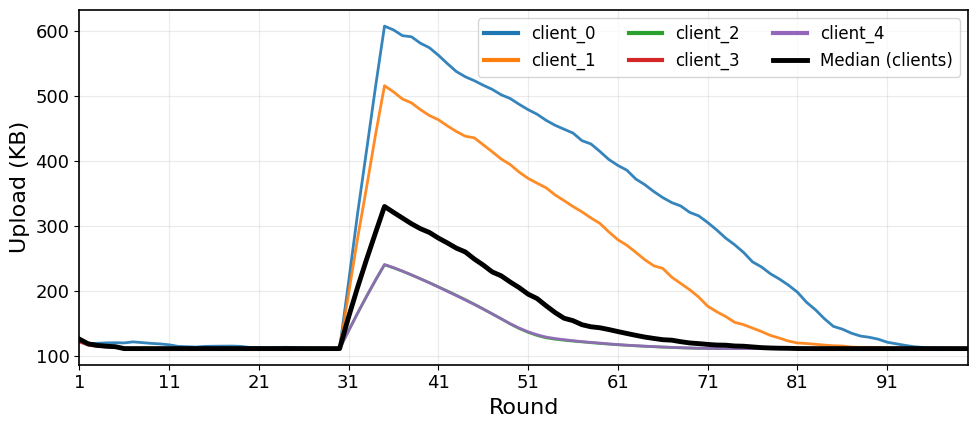

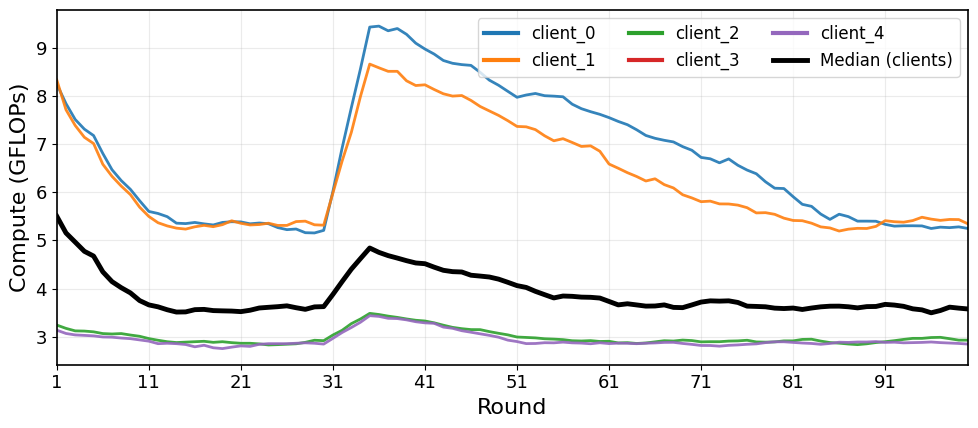

In [10]:
# Simplified paper-ready spaghetti plots (non-IID CIFAR-10, full_perclient.csv)
# - Only Upload + Compute
# - One figure per plot
# - No titles
# - Larger fonts/axes labels/ticks
# - Show each client as a colored line
# - Show ONLY the median across clients (thick black)
# - Add legend mapping colors -> client_id
#
# NOTE: Upload is shown on PER-CLIENT scale, so agg is not plotted here.
#       (If you want agg too, tell me: per-client (agg/#clients) OR total (sum clients).)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

csv_path = r"ablations/noniid/full_perclient.csv"
df = pd.read_csv(csv_path)
df["round"] = pd.to_numeric(df["round"], errors="coerce")
df = df.dropna(subset=["round"])

df = df[df["client_id"] != "agg"].copy()
df = df.sort_values(["client_id", "round"])

clients = sorted(df["client_id"].unique())
rounds = np.sort(df["round"].unique())

# Derived
df["upload_kb"] = df["upload_bytes"] / 1024.0
df["gflops"] = df["flops"] / 1e9

# Styling (bigger, paper-like)
plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 12,
    "axes.linewidth": 1.2,
})

tick_step = 10
smooth_window = 5  # set 1 for no smoothing

cmap = plt.cm.tab10(np.linspace(0, 1, max(10, len(clients))))
client_color = {cid: cmap[i] for i, cid in enumerate(clients)}

def rolling(s, w):
    if w is None or w <= 1:
        return s
    return s.rolling(w, min_periods=1).mean()

def median_over_clients(value_col):
    pr = df.groupby("round")[value_col].median().reset_index().sort_values("round")
    pr["median"] = rolling(pr[value_col], smooth_window)
    return pr[["round", "median"]]

def plot_spaghetti(value_col, ylabel):
    fig, ax = plt.subplots(figsize=(10, 4.5))

    # Per-client lines
    for cid in clients:
        sub = df[df["client_id"] == cid].sort_values("round")
        ax.plot(
            sub["round"],
            rolling(sub[value_col], smooth_window),
            color=client_color[cid],
            linewidth=2.0,
            alpha=0.9
        )

    # Median line
    med = median_over_clients(value_col)
    ax.plot(med["round"], med["median"], color="black", linewidth=3.5, label="Median (clients)")

    # Axes / ticks
    ax.set_xlabel("Round")
    ax.set_ylabel(ylabel)
    ax.set_xticks(np.arange(rounds.min(), rounds.max() + 1, tick_step))
    ax.set_xlim(rounds.min(), rounds.max())
    ax.grid(True, alpha=0.25)

    # Legend: client colors + median
    handles = [Line2D([0],[0], color=client_color[c], lw=3, label=c) for c in clients]
    handles.append(Line2D([0],[0], color="black", lw=3.5, label="Median (clients)"))
    ax.legend(handles=handles, ncol=3, frameon=True, loc="upper right")

    plt.tight_layout()
    plt.show()

# Plot 1: Upload
plot_spaghetti("upload_kb", "Upload (KB)")

# Plot 2: Compute
plot_spaghetti("gflops", "Compute (GFLOPs)")

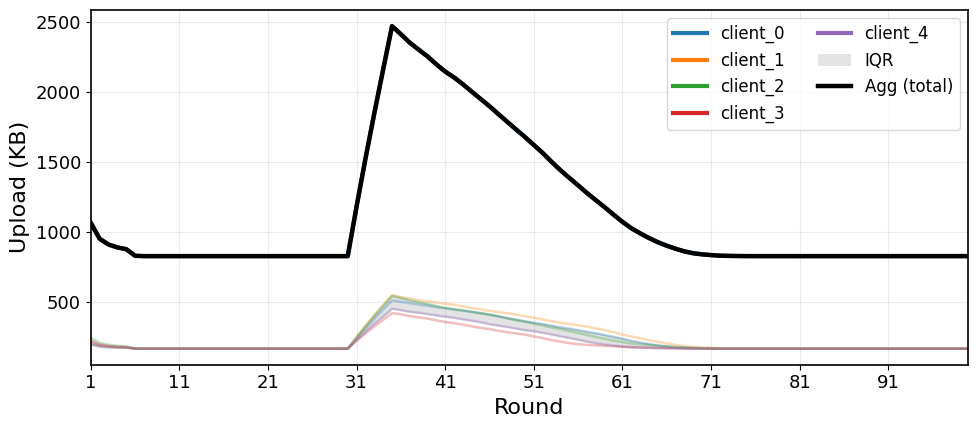

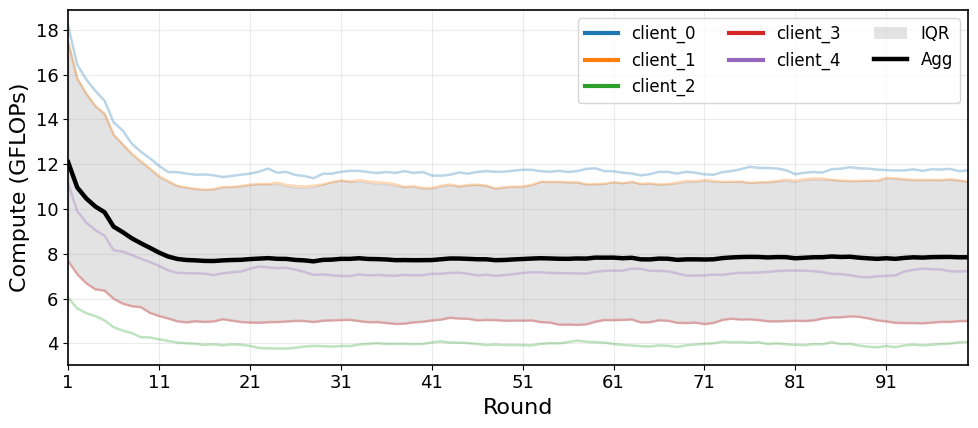

In [17]:
# Spaghetti (Upload + Compute), standalone plots, paper-ready
# - per-client colored lines (faint)
# - gray IQR band across clients
# - black Agg line
# - Upload uses REALISTIC TOTAL scale: compare SUM(client uploads) vs Agg upload
#   (Agg upload in your CSV appears to be total upload across participating clients)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

csv_path = r"notebooks/results/speechcommands_metrics_with_client_id.csv"
df = pd.read_csv(csv_path)
df["round"] = pd.to_numeric(df["round"], errors="coerce")
df = df.dropna(subset=["round"])

df_clients = df[df["client_id"] != "agg"].copy().sort_values(["client_id", "round"])
df_agg = df[df["client_id"] == "agg"].copy().sort_values(["round"])

clients = sorted(df_clients["client_id"].unique())
rounds = np.sort(df_clients["round"].unique())

# Derived
df_clients["upload_kb"] = df_clients["upload_bytes"] / 1024.0
df_clients["gflops"] = df_clients["flops"] / 1e9
df_agg["upload_kb"] = df_agg["upload_bytes"] / 1024.0
df_agg["gflops"] = df_agg["flops"] / 1e9

# Styling
plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 12,
    "axes.linewidth": 1.2,
})

tick_step = 10
smooth_window = 5  # set 1 for no smoothing

cmap = plt.cm.tab10(np.linspace(0, 1, max(10, len(clients))))
client_color = {cid: cmap[i] for i, cid in enumerate(clients)}

def rolling(s, w):
    if w is None or w <= 1:
        return s
    return s.rolling(w, min_periods=1).mean()

def set_round_ticks(ax):
    ax.set_xticks(np.arange(rounds.min(), rounds.max() + 1, tick_step))
    ax.set_xlim(rounds.min(), rounds.max())
    ax.grid(True, alpha=0.25)

def plot_upload_total():
    # client total per round
    total = df_clients.groupby("round")["upload_kb"].sum().reset_index().sort_values("round")
    total["sum_clients_s"] = rolling(total["upload_kb"], smooth_window)

    # IQR across clients (per-client distribution per round)
    pr = df_clients.groupby("round")["upload_kb"].agg(
        q25=lambda x: np.quantile(x, 0.25),
        q75=lambda x: np.quantile(x, 0.75),
    ).reset_index().sort_values("round")
    pr["q25"] = rolling(pr["q25"], smooth_window)
    pr["q75"] = rolling(pr["q75"], smooth_window)

    # agg total
    agg = df_agg[["round", "upload_kb"]].copy().sort_values("round")
    agg["agg_s"] = rolling(agg["upload_kb"], smooth_window)

    fig, ax = plt.subplots(figsize=(10, 4.5))

    # per-client faint lines (for contribution feel)
    for cid in clients:
        sub = df_clients[df_clients["client_id"] == cid].sort_values("round")
        ax.plot(sub["round"], rolling(sub["upload_kb"], smooth_window),
                color=client_color[cid], linewidth=1.8, alpha=0.30)

    # IQR band (per-client)
    ax.fill_between(pr["round"], pr["q25"], pr["q75"], color="gray", alpha=0.22)

    # total sum + agg total
    ax.plot(total["round"], total["sum_clients_s"], color="tab:blue", linewidth=3.0)
    ax.plot(agg["round"], agg["agg_s"], color="black", linewidth=3.2)

    ax.set_xlabel("Round")
    ax.set_ylabel("Upload (KB)")
    set_round_ticks(ax)

    handles = [Line2D([0],[0], color=client_color[c], lw=3, label=c) for c in clients]
    handles += [
        Patch(facecolor="gray", alpha=0.22, label="IQR"),
        
        Line2D([0],[0], color="black", lw=3.2, label="Agg (total)"),
    ]
    ax.legend(handles=handles, ncol=2, frameon=True, loc="upper right")

    plt.tight_layout()
    plt.show()

def plot_compute():
    # IQR across clients (GFLOPs per client per round)
    pr = df_clients.groupby("round")["gflops"].agg(
        q25=lambda x: np.quantile(x, 0.25),
        q75=lambda x: np.quantile(x, 0.75),
    ).reset_index().sort_values("round")
    pr["q25"] = rolling(pr["q25"], smooth_window)
    pr["q75"] = rolling(pr["q75"], smooth_window)

    agg = df_agg[["round", "gflops"]].copy().sort_values("round")
    agg["agg_s"] = rolling(agg["gflops"], smooth_window)

    fig, ax = plt.subplots(figsize=(10, 4.5))

    for cid in clients:
        sub = df_clients[df_clients["client_id"] == cid].sort_values("round")
        ax.plot(sub["round"], rolling(sub["gflops"], smooth_window),
                color=client_color[cid], linewidth=1.8, alpha=0.30)

    ax.fill_between(pr["round"], pr["q25"], pr["q75"], color="gray", alpha=0.22)
    ax.plot(agg["round"], agg["agg_s"], color="black", linewidth=3.2)

    ax.set_xlabel("Round")
    ax.set_ylabel("Compute (GFLOPs)")
    set_round_ticks(ax)

    handles = [Line2D([0],[0], color=client_color[c], lw=3, label=c) for c in clients]
    handles += [
        Patch(facecolor="gray", alpha=0.22, label="IQR"),
        Line2D([0],[0], color="black", lw=3.2, label="Agg"),
    ]
    ax.legend(handles=handles, ncol=3, frameon=True, loc="upper right")

    plt.tight_layout()
    plt.show()

plot_upload_total()
plot_compute()

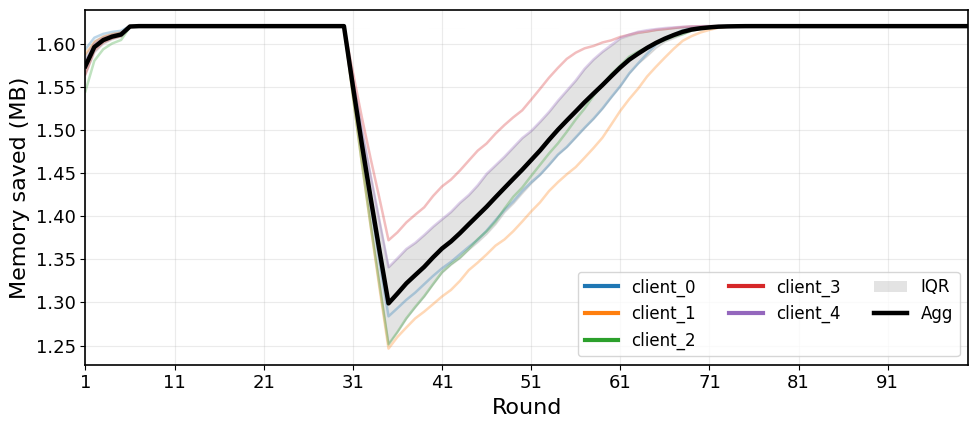

In [18]:
# Add a standalone spaghetti plot for Memory saved (non-IID CIFAR-10)
# Same style as upload/compute:
# - per-client colored faint lines
# - gray IQR band across clients
# - black Agg overlay

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

csv_path = r"notebooks/results/speechcommands_metrics_with_client_id.csv"
df = pd.read_csv(csv_path)
df["round"] = pd.to_numeric(df["round"], errors="coerce")
df = df.dropna(subset=["round"])

df_clients = df[df["client_id"] != "agg"].copy().sort_values(["client_id", "round"])
df_agg = df[df["client_id"] == "agg"].copy().sort_values(["round"])

clients = sorted(df_clients["client_id"].unique())
rounds = np.sort(df_clients["round"].unique())

# Styling (match your other plots)
plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 12,
    "axes.linewidth": 1.2,
})

tick_step = 10
smooth_window = 5  # set 1 for no smoothing

cmap = plt.cm.tab10(np.linspace(0, 1, max(10, len(clients))))
client_color = {cid: cmap[i] for i, cid in enumerate(clients)}

def rolling(s, w):
    if w is None or w <= 1:
        return s
    return s.rolling(w, min_periods=1).mean()

def set_round_ticks(ax):
    ax.set_xticks(np.arange(rounds.min(), rounds.max() + 1, tick_step))
    ax.set_xlim(rounds.min(), rounds.max())
    ax.grid(True, alpha=0.25)

# IQR across clients (memory_saved is in MB in your CSV)
pr = df_clients.groupby("round")["memory_saved"].agg(
    q25=lambda x: np.quantile(x, 0.25),
    q75=lambda x: np.quantile(x, 0.75),
).reset_index().sort_values("round")
pr["q25"] = rolling(pr["q25"], smooth_window)
pr["q75"] = rolling(pr["q75"], smooth_window)

# Agg series (assumed comparable scale)
agg = df_agg[["round", "memory_saved"]].copy().sort_values("round")
agg["agg_s"] = rolling(agg["memory_saved"], smooth_window)

fig, ax = plt.subplots(figsize=(10, 4.5))

# per-client faint lines
for cid in clients:
    sub = df_clients[df_clients["client_id"] == cid].sort_values("round")
    ax.plot(sub["round"], rolling(sub["memory_saved"], smooth_window),
            color=client_color[cid], linewidth=1.8, alpha=0.30)

# IQR band
ax.fill_between(pr["round"], pr["q25"], pr["q75"], color="gray", alpha=0.22)

# Agg overlay
ax.plot(agg["round"], agg["agg_s"], color="black", linewidth=3.2)

ax.set_xlabel("Round")
ax.set_ylabel("Memory saved (MB)")
set_round_ticks(ax)

handles = [Line2D([0],[0], color=client_color[c], lw=3, label=c) for c in clients]
handles += [
    Patch(facecolor="gray", alpha=0.22, label="IQR"),
    Line2D([0],[0], color="black", lw=3.2, label="Agg"),
]
ax.legend(handles=handles, ncol=3, frameon=True, loc="lower right")

plt.tight_layout()
plt.show()

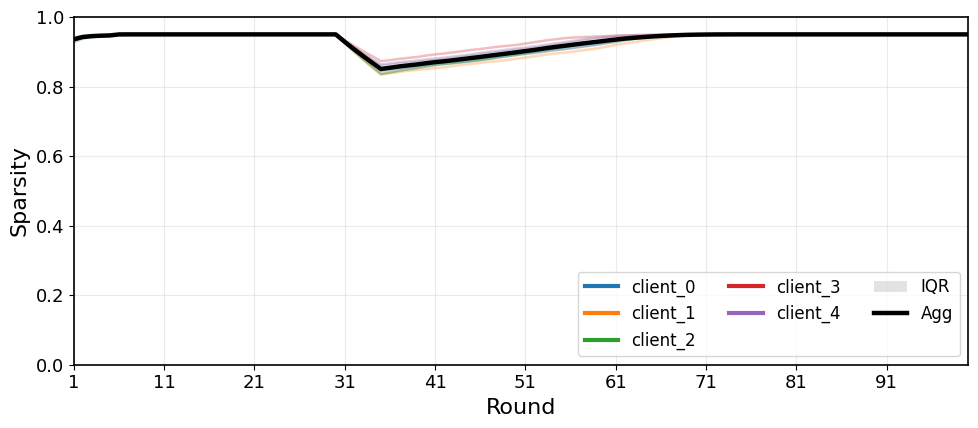

In [19]:
# Add a standalone spaghetti plot for Sparsity (Speech Commands)
# Same style as upload/compute/memory:
# - per-client colored faint lines
# - gray IQR band across clients
# - black Agg overlay

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

csv_path = r"notebooks/results/speechcommands_metrics_with_client_id.csv"
df = pd.read_csv(csv_path)
df["round"] = pd.to_numeric(df["round"], errors="coerce")
df = df.dropna(subset=["round"])

df_clients = df[df["client_id"] != "agg"].copy().sort_values(["client_id", "round"])
df_agg = df[df["client_id"] == "agg"].copy().sort_values(["round"])

clients = sorted(df_clients["client_id"].unique())
rounds = np.sort(df_clients["round"].unique())

# ---- pick the sparsity column (common options) ----
# If your CSV uses a different name, replace "sparsity" below.
sparsity_col = None
for c in ["sparsity", "avg_sparsity", "sparsity_pct", "density", "density_pct"]:
    if c in df.columns:
        sparsity_col = c
        break
if sparsity_col is None:
    raise KeyError("No sparsity column found. Expected one of: "
                   "sparsity, avg_sparsity, sparsity_pct, density, density_pct")

# Convert to a unified 'sparsity' in [0,1] (best effort)
def to_unit_sparsity(series, colname):
    s = series.astype(float)
    if "density" in colname:
        # density -> sparsity
        # if density is in percent, normalize first
        if s.max() > 1.5:
            s = s / 100.0
        return 1.0 - s
    else:
        # sparsity already, maybe in percent
        if s.max() > 1.5:
            s = s / 100.0
        return s

df_clients["sparsity_unit"] = to_unit_sparsity(df_clients[sparsity_col], sparsity_col)
df_agg["sparsity_unit"] = to_unit_sparsity(df_agg[sparsity_col], sparsity_col)

# Styling (match your other plots)
plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 12,
    "axes.linewidth": 1.2,
})

tick_step = 10
smooth_window = 5  # set 1 for no smoothing

cmap = plt.cm.tab10(np.linspace(0, 1, max(10, len(clients))))
client_color = {cid: cmap[i] for i, cid in enumerate(clients)}

def rolling(s, w):
    if w is None or w <= 1:
        return s
    return s.rolling(w, min_periods=1).mean()

def set_round_ticks(ax):
    ax.set_xticks(np.arange(rounds.min(), rounds.max() + 1, tick_step))
    ax.set_xlim(rounds.min(), rounds.max())
    ax.grid(True, alpha=0.25)

# IQR across clients
pr = df_clients.groupby("round")["sparsity_unit"].agg(
    q25=lambda x: np.quantile(x, 0.25),
    q75=lambda x: np.quantile(x, 0.75),
).reset_index().sort_values("round")
pr["q25"] = rolling(pr["q25"], smooth_window)
pr["q75"] = rolling(pr["q75"], smooth_window)

# Agg series
agg = df_agg[["round", "sparsity_unit"]].copy().sort_values("round")
agg["agg_s"] = rolling(agg["sparsity_unit"], smooth_window)

fig, ax = plt.subplots(figsize=(10, 4.5))

# per-client faint lines
for cid in clients:
    sub = df_clients[df_clients["client_id"] == cid].sort_values("round")
    ax.plot(sub["round"], rolling(sub["sparsity_unit"], smooth_window),
            color=client_color[cid], linewidth=1.8, alpha=0.30)

# IQR band
ax.fill_between(pr["round"], pr["q25"], pr["q75"], color="gray", alpha=0.22)

# Agg overlay
ax.plot(agg["round"], agg["agg_s"], color="black", linewidth=3.2)

ax.set_xlabel("Round")
ax.set_ylabel("Sparsity")
ax.set_ylim(0.0, 1.0)
set_round_ticks(ax)

handles = [Line2D([0],[0], color=client_color[c], lw=3, label=str(c)) for c in clients]
handles += [
    Patch(facecolor="gray", alpha=0.22, label="IQR"),
    Line2D([0],[0], color="black", lw=3.2, label="Agg"),
]
ax.legend(handles=handles, ncol=3, frameon=True, loc="lower right")

plt.tight_layout()
plt.show()

In [5]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")

ROOT = Path(r"c:\Users\la7tim\Desktop\Internship\FedTinyProp")
ABL_DIR = ROOT / "ablations" / "medium"

# Optional: set True if you want files saved under ROOT/figures/ablations_medium
SAVE_FIGS = False
OUT_DIR = ROOT / "figures" / "ablations_medium"
OUT_DIR.mkdir(parents=True, exist_ok=True)

def savefig(name: str):
    if SAVE_FIGS:
        plt.savefig(OUT_DIR / name, dpi=300, bbox_inches="tight")

In [7]:
files = {
    "Dense": ABL_DIR / "dense.csv",
    "Fixed Top-k": ABL_DIR / "fixed_topk.csv",
    "Adapt-only": ABL_DIR / "adapt_only.csv",
    "Skip-only": ABL_DIR / "skip_only.csv",
    "Full": ABL_DIR / "full.csv",
}

dfs = []
for label, p in files.items():
    df = pd.read_csv(p)
    df["variant"] = label
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)

# Basic derived metrics
df_all["round"] = df_all["round"].astype(int)
df_all["accuracy_pct"] = df_all["accuracy"] * 100.0
df_all["gflops"] = df_all["flops"] / 1e9

# Total comm (bytes) = download + upload (dense usually has upload==download)
df_all["total_comm_bytes"] = df_all["download_bytes"] + df_all["upload_bytes"]
df_all["total_comm_mb"] = df_all["total_comm_bytes"] / (1024 * 1024)
df_all["upload_mb"] = df_all["upload_bytes"] / (1024 * 1024)
df_all["download_mb"] = df_all["download_bytes"] / (1024 * 1024)

# Make sure these columns exist even if some variants lack them
for col in ["skipped_batches", "effective_compute_ratio", "memory_saved", "latency_ms", "time_total_ms"]:
    if col not in df_all.columns:
        df_all[col] = np.nan

df_all.head(3)

,timestamp,round,method,accuracy,flops,dense_flops_ref,saved_flops_est,saved_flops_ratio,rigl_sparsity,memory,...,saved_upload_bytes,saved_upload_ratio,client_eval_history,variant,accuracy_pct,gflops,total_comm_bytes,total_comm_mb,upload_mb,download_mb
0,2026-01-13 21:11:54,1,Dense,0.27278,2.919931e+10,2.920826e+10,8945664.0,0.000306,0.0,43.178627,...,0.0,0.0,"{0: 0.213, 1: 0.2823, 2: 0.3488, 3: 0.32, 4: 0...",Dense,27.278,29.19931,12346000,11.774063,5.887032,5.887032
1,2026-01-13 21:14:30,2,Dense,0.32614,2.919931e+10,2.920826e+10,8945664.0,0.000306,0.0,44.356033,...,0.0,0.0,"{0: 0.2719, 1: 0.3525, 2: 0.4001, 3: 0.36, 4: ...",Dense,32.614,29.19931,12346000,11.774063,5.887032,5.887032
2,2026-01-13 21:17:05,3,Dense,0.35244,2.919931e+10,2.920826e+10,8945664.0,0.000306,0.0,44.356033,...,0.0,0.0,"{0: 0.2849, 1: 0.3946, 2: 0.3898, 3: 0.3628, 4...",Dense,35.244,29.19931,12346000,11.774063,5.887032,5.887032


In [8]:
# Average over last N rounds to smooth noise
N_LAST = 10
last_round = df_all["round"].max()
tail_df = df_all[df_all["round"] > last_round - N_LAST].copy()

summary = (
    tail_df.groupby("variant", as_index=False)
    .agg(
        accuracy_pct=("accuracy_pct", "mean"),
        gflops=("gflops", "mean"),
        sparsity=("sparsity", "mean"),
        latency_ms=("latency_ms", "mean"),
        time_total_ms=("time_total_ms", "mean"),
        total_comm_mb=("total_comm_mb", "mean"),
        upload_mb=("upload_mb", "mean"),
        memory=("memory", "mean"),
        memory_saved=("memory_saved", "mean"),
        skipped_batches=("skipped_batches", "mean"),
        ecr=("effective_compute_ratio", "mean"),
        compression_ratio=("compression_ratio", "mean"),
    )
)

# Nice ordering
order = ["Dense", "Fixed Top-k", "Adapt-only", "Skip-only", "Full"]
summary["variant"] = pd.Categorical(summary["variant"], categories=order, ordered=True)
summary = summary.sort_values("variant")

summary

,variant,accuracy_pct,gflops,sparsity,latency_ms,time_total_ms,total_comm_mb,upload_mb,memory,memory_saved,skipped_batches,ecr,compression_ratio
1,Dense,65.5312,29.199310,0.000000,4.936886,16122.723402,11.774063,5.887032,44.356033,0.000000,0.0,1.000000,1.000000
2,Fixed Top-k,65.5768,17.395175,0.500000,4.620695,21658.272688,11.354151,5.467119,44.356033,0.083982,0.0,1.000000,1.076807
0,Adapt-only,65.1478,8.712497,0.878691,3.841543,22010.597196,7.213391,1.326359,44.356033,0.912099,0.0,1.000000,4.476611
4,Skip-only,62.7712,15.139620,0.000000,4.941559,21920.972224,11.774063,5.887032,44.356033,0.000000,753.6,0.518466,1.000000
3,Full,61.1994,4.744367,0.860753,4.118276,22888.219582,7.409529,1.522497,44.356033,0.872878,754.4,0.517955,3.899877


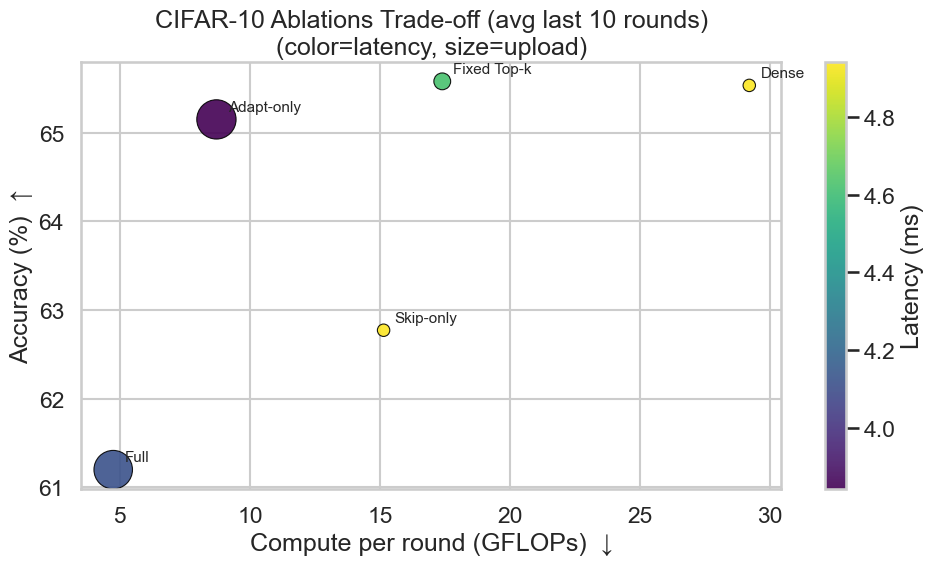

In [9]:
plt.figure(figsize=(10, 6))
plot_df = summary.dropna(subset=["accuracy_pct", "gflops"]).copy()

# Marker size scaling based on upload
min_s, max_s = 80, 800
if plot_df["upload_mb"].notna().any():
    u = plot_df["upload_mb"].fillna(plot_df["upload_mb"].median())
    u_norm = (u - u.min()) / (u.max() - u.min() + 1e-12)
    plot_df["msize"] = min_s + (max_s - min_s) * (1 - u_norm)  # smaller upload -> bigger marker
else:
    plot_df["msize"] = 200

sc = plt.scatter(
    plot_df["gflops"],
    plot_df["accuracy_pct"],
    c=plot_df["latency_ms"],
    s=plot_df["msize"],
    cmap="viridis",
    alpha=0.9,
    edgecolor="black",
    linewidth=0.8,
)

for _, r in plot_df.iterrows():
    plt.annotate(r["variant"], (r["gflops"], r["accuracy_pct"]), xytext=(8, 6), textcoords="offset points", fontsize=11)

cbar = plt.colorbar(sc)
cbar.set_label("Latency (ms)")

plt.xlabel("Compute per round (GFLOPs)  ↓")
plt.ylabel("Accuracy (%)  ↑")
plt.title(f"CIFAR-10 Ablations Trade-off (avg last {N_LAST} rounds)\n(color=latency, size=upload)")
plt.tight_layout()
savefig("ablations_pareto_accuracy_vs_gflops.png")
plt.show()

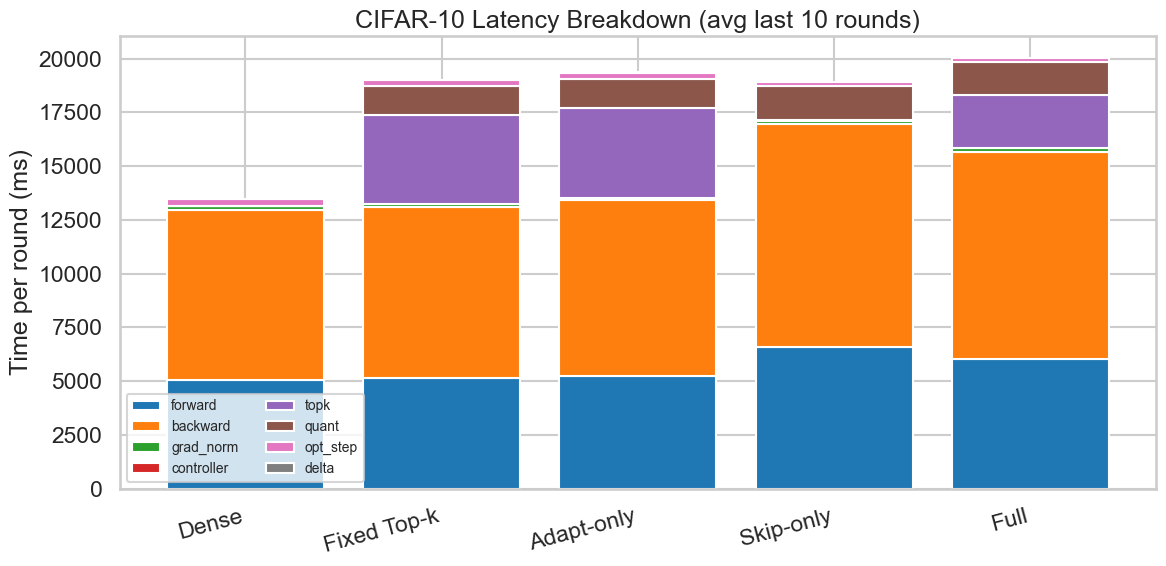

In [10]:
# Use last-window average to avoid spiky timing
timing_cols = [
    "time_forward_ms",
    "time_backward_ms",
    "time_grad_norm_ms",
    "time_controller_ms",
    "time_topk_ms",
    "time_quant_ms",
    "time_opt_step_ms",
    "time_delta_ms",
]

timing = tail_df.groupby("variant", as_index=False)[timing_cols].mean()
timing["variant"] = pd.Categorical(timing["variant"], categories=order, ordered=True)
timing = timing.sort_values("variant").set_index("variant")

# Some methods may have zeros; keep them
timing_plot = timing.fillna(0.0)

plt.figure(figsize=(12, 6))
bottom = np.zeros(len(timing_plot))

colors = sns.color_palette("tab10", n_colors=len(timing_cols))
x = np.arange(len(timing_plot.index))

for i, col in enumerate(timing_cols):
    vals = timing_plot[col].values
    plt.bar(x, vals, bottom=bottom, label=col.replace("time_", "").replace("_ms", ""), color=colors[i])
    bottom += vals

plt.xticks(x, timing_plot.index, rotation=15, ha="right")
plt.ylabel("Time per round (ms)")
plt.title(f"CIFAR-10 Latency Breakdown (avg last {N_LAST} rounds)")
plt.legend(ncol=2, fontsize=10, frameon=True)
plt.tight_layout()
savefig("ablations_latency_breakdown_stacked.png")
plt.show()

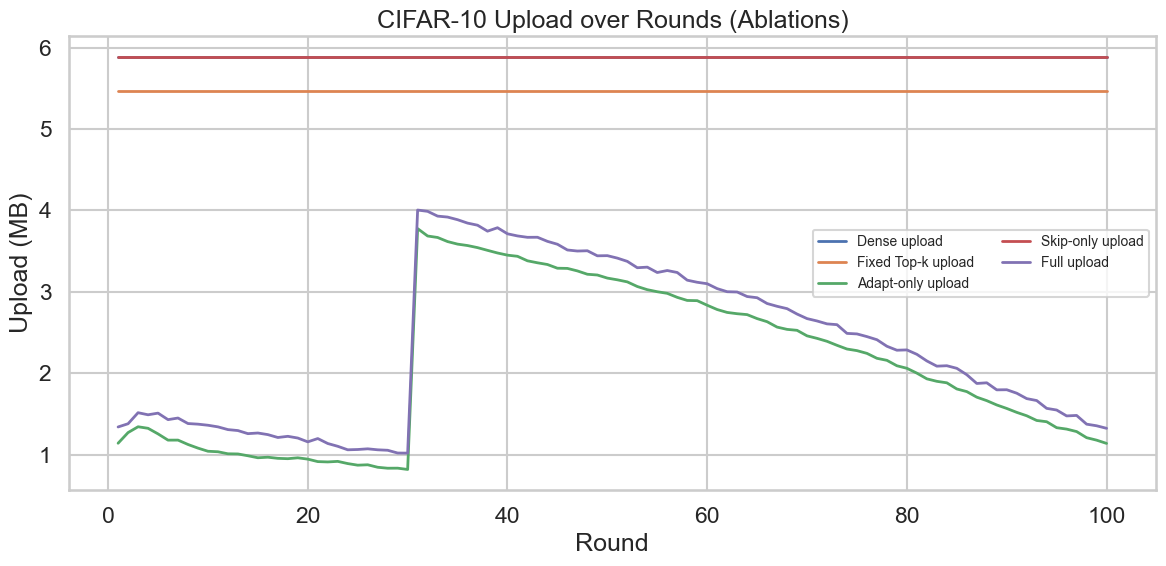

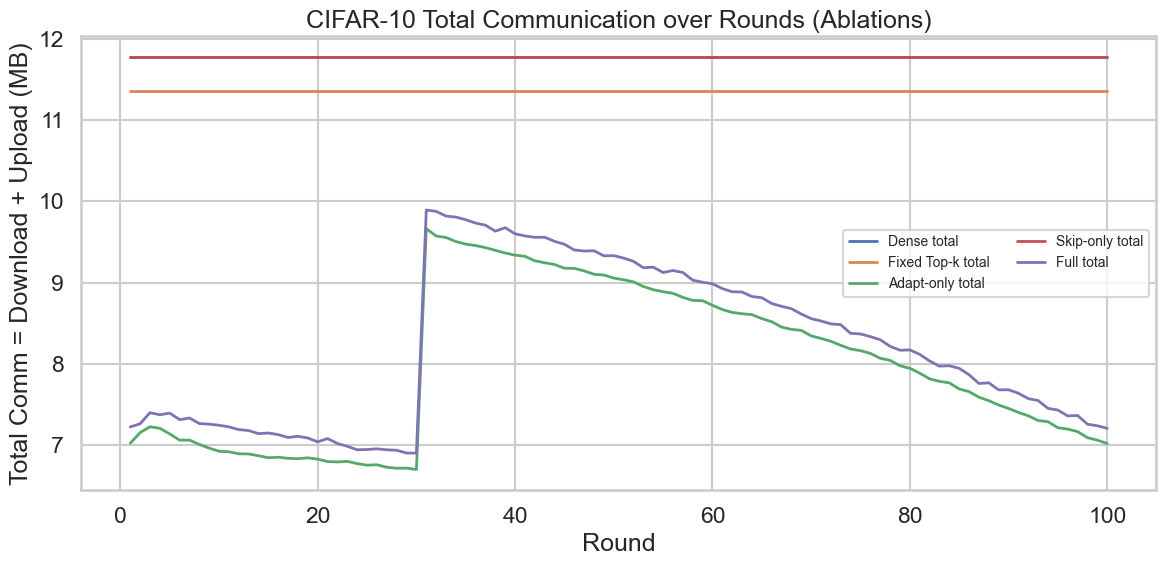

In [11]:
plt.figure(figsize=(12, 6))

for label in order:
    d = df_all[df_all["variant"] == label].sort_values("round")
    plt.plot(d["round"], d["upload_mb"], label=f"{label} upload", linewidth=2)

plt.xlabel("Round")
plt.ylabel("Upload (MB)")
plt.title("CIFAR-10 Upload over Rounds (Ablations)")
plt.legend(ncol=2, fontsize=10)
plt.tight_layout()
savefig("ablations_upload_over_rounds.png")
plt.show()

plt.figure(figsize=(12, 6))
for label in order:
    d = df_all[df_all["variant"] == label].sort_values("round")
    plt.plot(d["round"], d["total_comm_mb"], label=f"{label} total", linewidth=2)

plt.xlabel("Round")
plt.ylabel("Total Comm = Download + Upload (MB)")
plt.title("CIFAR-10 Total Communication over Rounds (Ablations)")
plt.legend(ncol=2, fontsize=10)
plt.tight_layout()
savefig("ablations_total_comm_over_rounds.png")
plt.show()

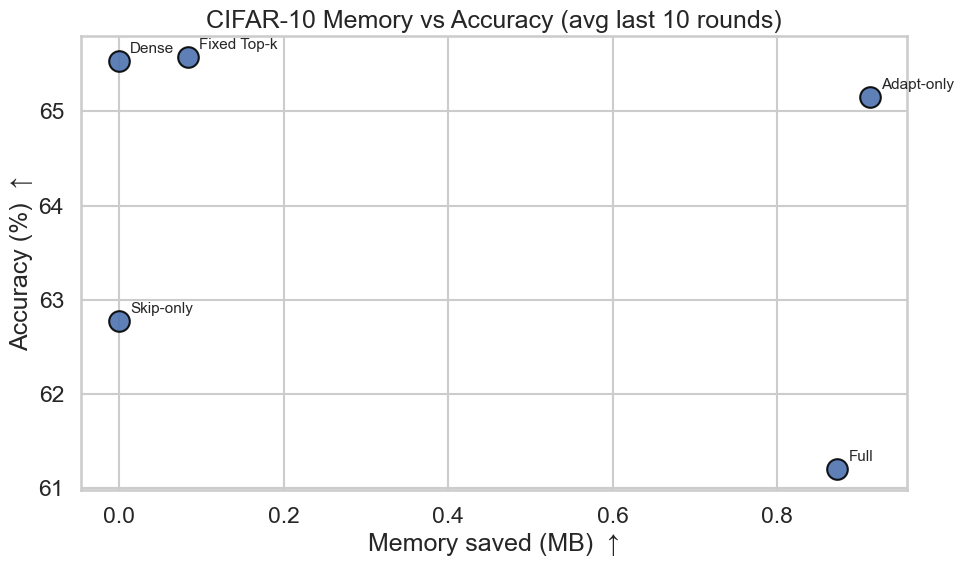

In [12]:
plt.figure(figsize=(10, 6))
plot_df = summary.dropna(subset=["accuracy_pct", "memory_saved"]).copy()

plt.scatter(plot_df["memory_saved"], plot_df["accuracy_pct"], s=220, alpha=0.9, edgecolor="black")
for _, r in plot_df.iterrows():
    plt.annotate(r["variant"], (r["memory_saved"], r["accuracy_pct"]), xytext=(8, 6), textcoords="offset points", fontsize=11)

plt.xlabel("Memory saved (MB)  ↑")
plt.ylabel("Accuracy (%)  ↑")
plt.title(f"CIFAR-10 Memory vs Accuracy (avg last {N_LAST} rounds)")
plt.tight_layout()
savefig("ablations_accuracy_vs_memory_saved.png")
plt.show()

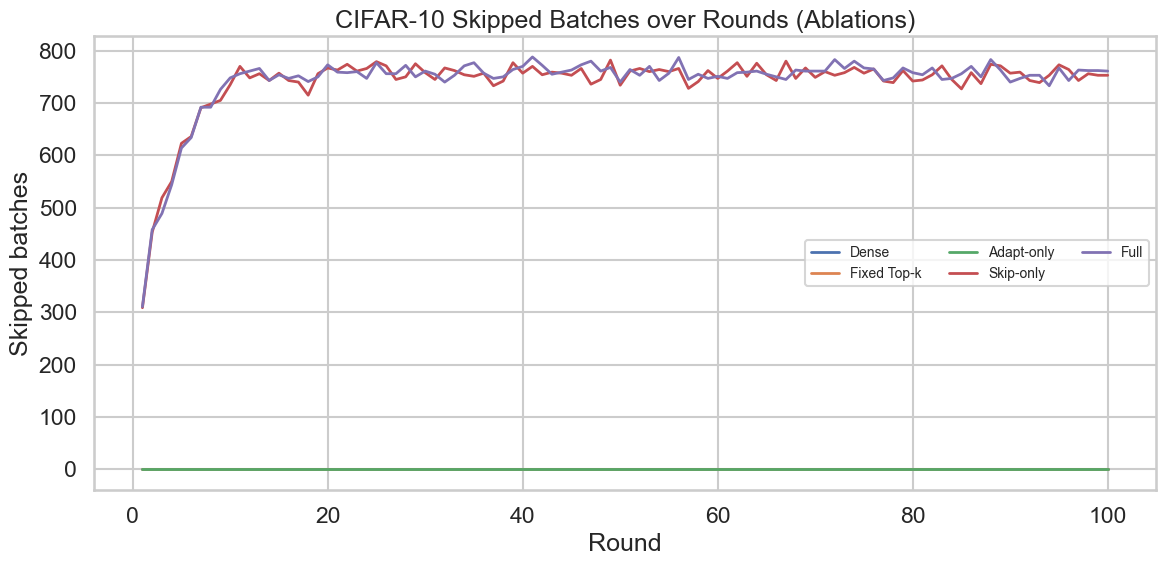

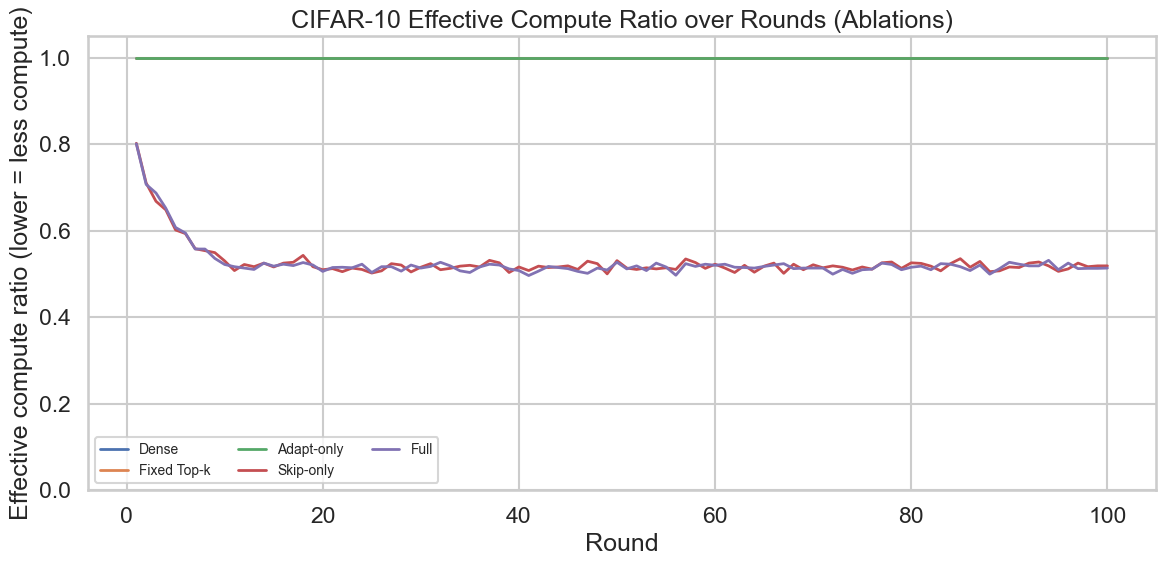

In [13]:
plt.figure(figsize=(12, 6))
for label in order:
    d = df_all[df_all["variant"] == label].sort_values("round")
    if d["skipped_batches"].notna().any():
        plt.plot(d["round"], d["skipped_batches"], label=label, linewidth=2)

plt.xlabel("Round")
plt.ylabel("Skipped batches")
plt.title("CIFAR-10 Skipped Batches over Rounds (Ablations)")
plt.legend(ncol=3, fontsize=10)
plt.tight_layout()
savefig("ablations_skipped_batches_over_rounds.png")
plt.show()

plt.figure(figsize=(12, 6))
for label in order:
    d = df_all[df_all["variant"] == label].sort_values("round")
    if d["effective_compute_ratio"].notna().any():
        plt.plot(d["round"], d["effective_compute_ratio"], label=label, linewidth=2)

plt.xlabel("Round")
plt.ylabel("Effective compute ratio (lower = less compute)")
plt.ylim(0, 1.05)
plt.title("CIFAR-10 Effective Compute Ratio over Rounds (Ablations)")
plt.legend(ncol=3, fontsize=10)
plt.tight_layout()
savefig("ablations_effective_compute_ratio_over_rounds.png")
plt.show()

In [14]:
cols = ["variant", "accuracy_pct", "gflops", "sparsity", "latency_ms", "total_comm_mb", "memory_saved", "skipped_batches", "ecr"]
tbl = summary[cols].copy()

# Formatting
tbl["accuracy_pct"] = tbl["accuracy_pct"].map(lambda x: f"{x:.2f}")
tbl["gflops"] = tbl["gflops"].map(lambda x: f"{x:.2f}")
tbl["sparsity"] = tbl["sparsity"].map(lambda x: f"{100*x:.1f}%" if pd.notna(x) else "")
tbl["latency_ms"] = tbl["latency_ms"].map(lambda x: f"{x:.1f}" if pd.notna(x) else "")
tbl["total_comm_mb"] = tbl["total_comm_mb"].map(lambda x: f"{x:.2f}" if pd.notna(x) else "")
tbl["memory_saved"] = tbl["memory_saved"].map(lambda x: f"{x:.2f}" if pd.notna(x) else "")
tbl["skipped_batches"] = tbl["skipped_batches"].map(lambda x: f"{x:.0f}" if pd.notna(x) else "")
tbl["ecr"] = tbl["ecr"].map(lambda x: f"{x:.2f}" if pd.notna(x) else "")

tbl

,variant,accuracy_pct,gflops,sparsity,latency_ms,total_comm_mb,memory_saved,skipped_batches,ecr
1,Dense,65.53,29.20,0.0%,4.9,11.77,0.00,0,1.00
2,Fixed Top-k,65.58,17.40,50.0%,4.6,11.35,0.08,0,1.00
0,Adapt-only,65.15,8.71,87.9%,3.8,7.21,0.91,0,1.00
4,Skip-only,62.77,15.14,0.0%,4.9,11.77,0.00,754,0.52
3,Full,61.20,4.74,86.1%,4.1,7.41,0.87,754,0.52


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def pareto_chart(series, title="", xlabel="", ylabel_left="Value", ylabel_right="Cumulative (%)", figsize=(11,6)):
    """
    series: pd.Series with index=category, values=numeric
    """
    s = series.dropna().sort_values(ascending=False)
    total = s.sum()
    cum = s.cumsum() / (total + 1e-12) * 100.0

    fig, ax1 = plt.subplots(figsize=figsize)
    bars = ax1.bar(s.index.astype(str), s.values, color="#4C78A8", alpha=0.9)
    ax1.set_ylabel(ylabel_left)
    ax1.set_xlabel(xlabel)
    ax1.set_title(title)
    ax1.tick_params(axis="x", rotation=20)

    ax2 = ax1.twinx()
    ax2.plot(s.index.astype(str), cum.values, color="#F58518", marker="o", linewidth=2.5)
    ax2.set_ylabel(ylabel_right)
    ax2.set_ylim(0, 105)
    ax2.axhline(80, color="gray", linestyle="--", linewidth=1)  # classic Pareto 80/20 reference

    # label cumulative points
    for i, v in enumerate(cum.values):
        ax2.annotate(f"{v:.1f}%", (i, v), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=10)

    plt.tight_layout()
    return fig

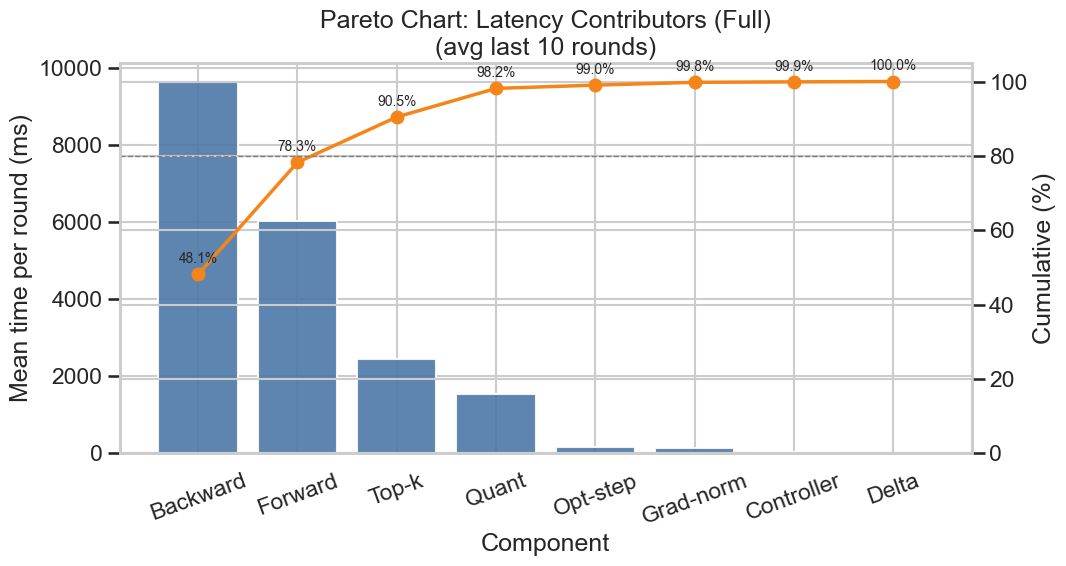

In [16]:
variant = "Full"   # change to: "Dense", "Fixed Top-k", "Adapt-only", "Skip-only", "Full"

timing_cols = [
    "time_forward_ms",
    "time_backward_ms",
    "time_grad_norm_ms",
    "time_controller_ms",
    "time_topk_ms",
    "time_quant_ms",
    "time_opt_step_ms",
    "time_delta_ms",
]

d = tail_df[tail_df["variant"] == variant].copy()
mean_t = d[timing_cols].mean().fillna(0.0)

# Rename labels to be prettier
pretty = {
    "time_forward_ms": "Forward",
    "time_backward_ms": "Backward",
    "time_grad_norm_ms": "Grad-norm",
    "time_controller_ms": "Controller",
    "time_topk_ms": "Top-k",
    "time_quant_ms": "Quant",
    "time_opt_step_ms": "Opt-step",
    "time_delta_ms": "Delta",
}
mean_t.index = [pretty.get(x, x) for x in mean_t.index]

fig = pareto_chart(
    mean_t,
    title=f"Pareto Chart: Latency Contributors ({variant})\n(avg last {N_LAST} rounds)",
    xlabel="Component",
    ylabel_left="Mean time per round (ms)",
)
plt.show()

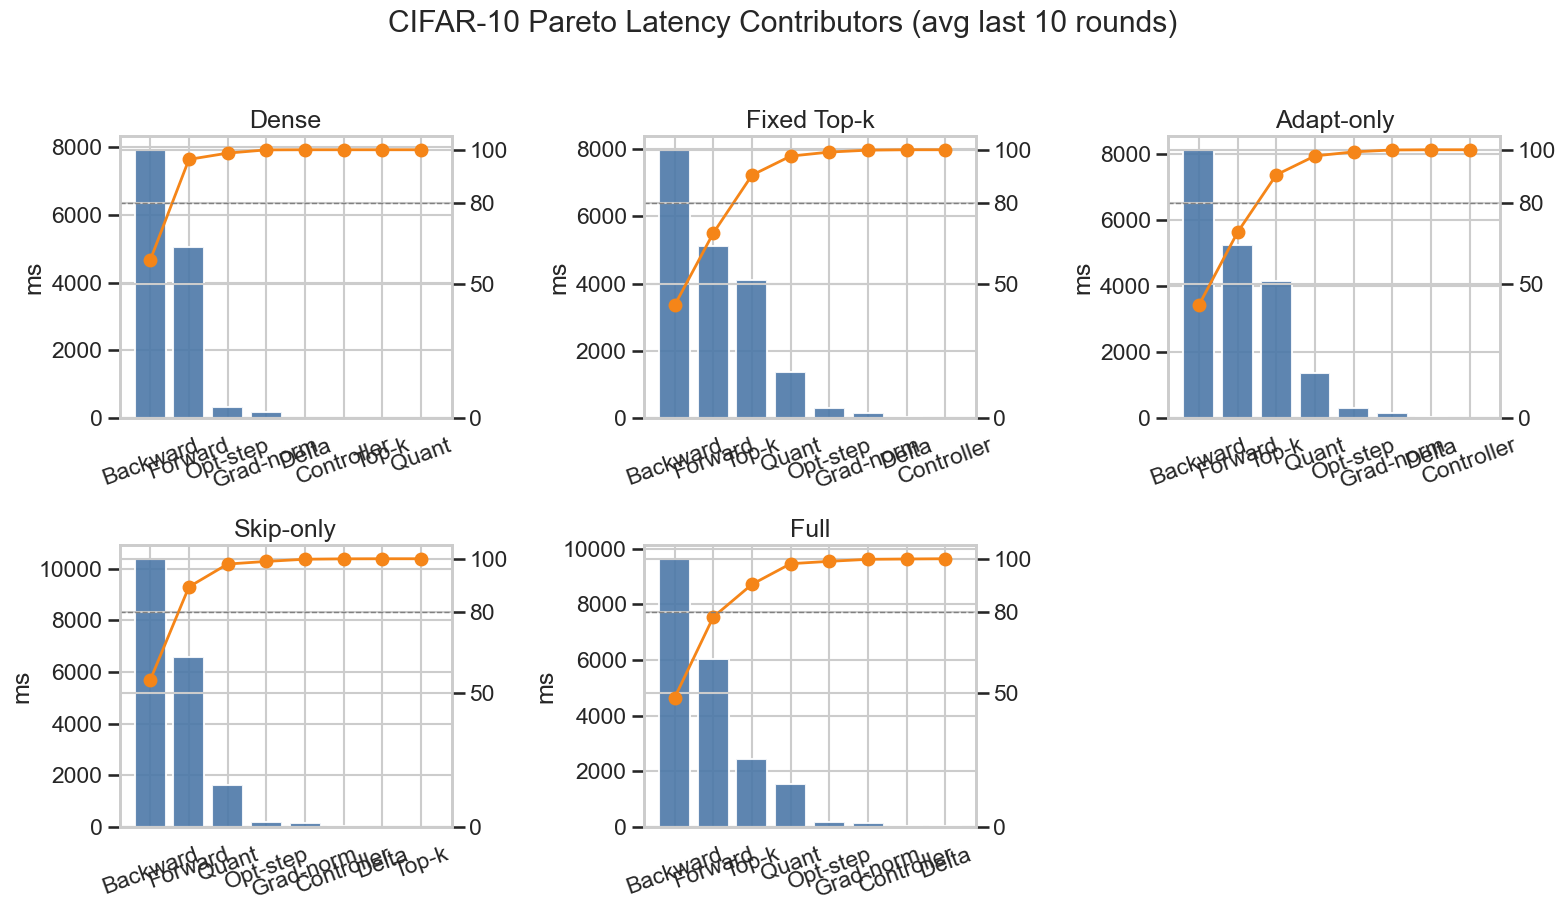

In [17]:
variants = ["Dense", "Fixed Top-k", "Adapt-only", "Skip-only", "Full"]
timing_cols = [
    "time_forward_ms",
    "time_backward_ms",
    "time_grad_norm_ms",
    "time_controller_ms",
    "time_topk_ms",
    "time_quant_ms",
    "time_opt_step_ms",
    "time_delta_ms",
]

pretty = {
    "time_forward_ms": "Forward",
    "time_backward_ms": "Backward",
    "time_grad_norm_ms": "Grad-norm",
    "time_controller_ms": "Controller",
    "time_topk_ms": "Top-k",
    "time_quant_ms": "Quant",
    "time_opt_step_ms": "Opt-step",
    "time_delta_ms": "Delta",
}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, variant in zip(axes, variants):
    d = tail_df[tail_df["variant"] == variant].copy()
    mean_t = d[timing_cols].mean().fillna(0.0)
    mean_t.index = [pretty.get(x, x) for x in mean_t.index]

    s = mean_t.sort_values(ascending=False)
    cum = s.cumsum() / (s.sum() + 1e-12) * 100.0

    ax.bar(s.index.astype(str), s.values, color="#4C78A8", alpha=0.9)
    ax2 = ax.twinx()
    ax2.plot(s.index.astype(str), cum.values, color="#F58518", marker="o", linewidth=2)
    ax2.set_ylim(0, 105)
    ax2.axhline(80, color="gray", linestyle="--", linewidth=1)

    ax.set_title(variant)
    ax.tick_params(axis="x", rotation=20)
    ax.set_ylabel("ms")
    ax2.set_yticks([0, 50, 80, 100])

# Hide any unused subplot
for j in range(len(variants), len(axes)):
    axes[j].axis("off")

plt.suptitle(f"CIFAR-10 Pareto Latency Contributors (avg last {N_LAST} rounds)", y=1.02)
plt.tight_layout()
plt.show()

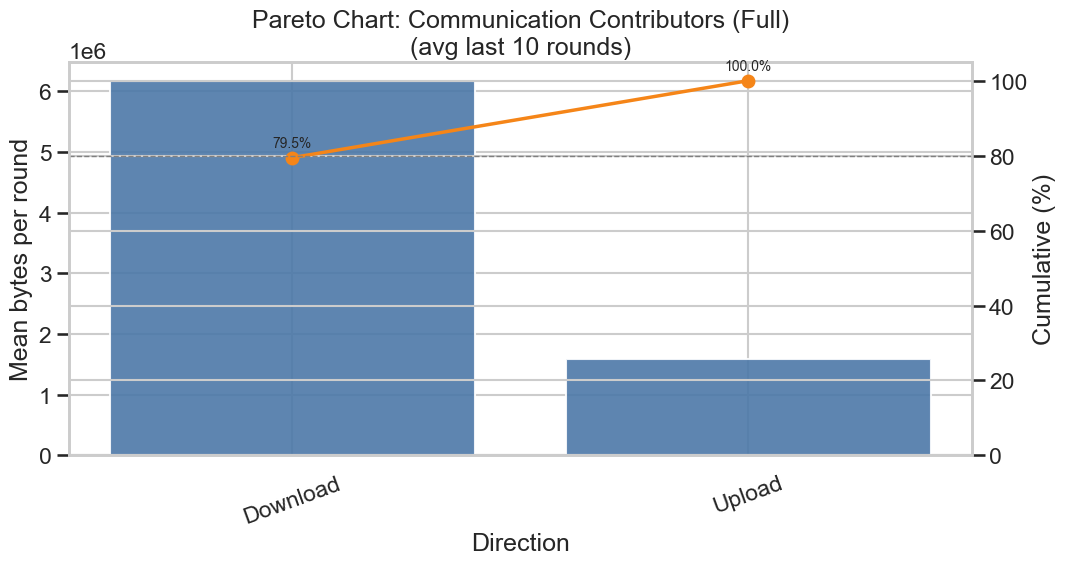

In [18]:
variant = "Full"
d = tail_df[tail_df["variant"] == variant].copy()

comm = pd.Series({
    "Download": d["download_bytes"].mean(),
    "Upload": d["upload_bytes"].mean(),
})

fig = pareto_chart(
    comm,
    title=f"Pareto Chart: Communication Contributors ({variant})\n(avg last {N_LAST} rounds)",
    xlabel="Direction",
    ylabel_left="Mean bytes per round",
)
plt.show()

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

variants = ["Full", "Skip-only", "Fixed Top-k"]  # choose any 3
timing_cols = [
    "time_forward_ms",
    "time_backward_ms",
    "time_grad_norm_ms",
    "time_controller_ms",
    "time_topk_ms",
    "time_quant_ms",
    "time_opt_step_ms",
    "time_delta_ms",
]

pretty = {
    "time_forward_ms": "Forward",
    "time_backward_ms": "Backward",
    "time_grad_norm_ms": "Grad-norm",
    "time_controller_ms": "Controller",
    "time_topk_ms": "Top-k",
    "time_quant_ms": "Quant",
    "time_opt_step_ms": "Opt-step",
    "time_delta_ms": "Delta",
}

# Mean timing per variant (avg last N_LAST rounds)
mean_t = (
    tail_df[tail_df["variant"].isin(variants)]
    .groupby("variant")[timing_cols]
    .mean()
    .fillna(0.0)
)

# Rename cols
mean_t = mean_t.rename(columns=pretty)

mean_t

,Forward,Backward,Grad-norm,Controller,Top-k,Quant,Opt-step,Delta
variant,,,,,,,,
Fixed Top-k,5129.308430,7981.710352,137.619388,0.000000,4114.25348,1354.165536,283.463724,28.802636
Full,6037.641040,9643.985296,150.724852,24.055266,2444.76336,1542.017568,176.498200,18.783280
Skip-only,6573.276706,10378.081102,154.941662,27.552094,0.00000,1612.732486,185.663262,6.843416


In [34]:
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerTuple

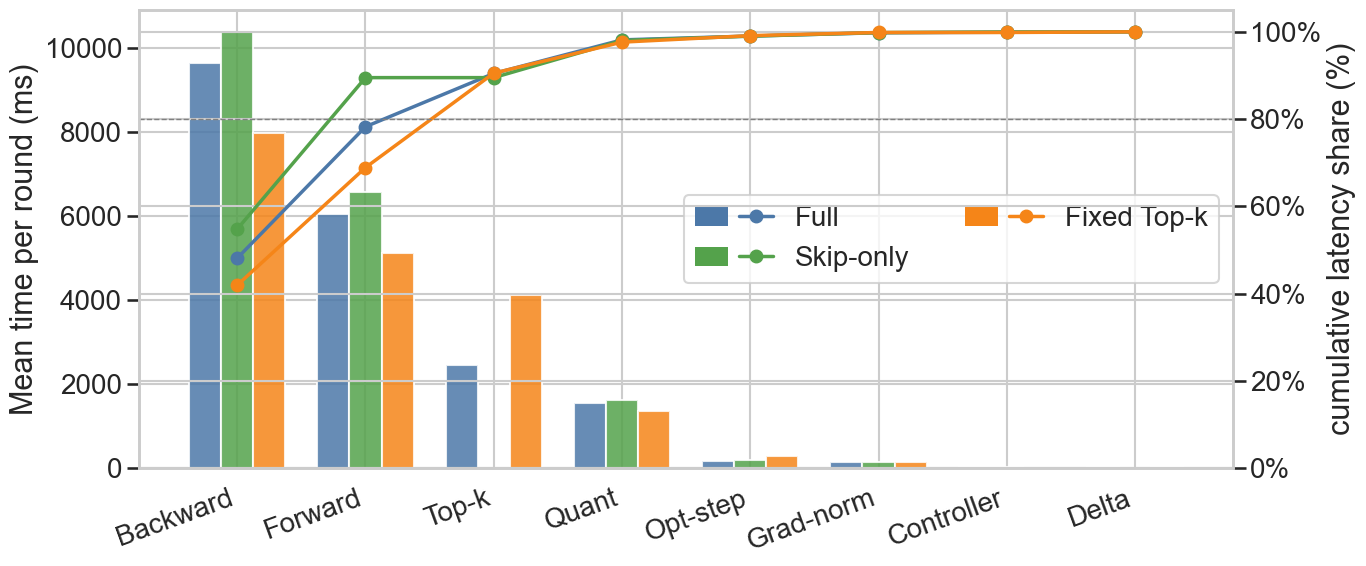

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from collections import OrderedDict

# Order components by Full (recommended)
ref = "Full"
comp_order = mean_t.loc[ref].sort_values(ascending=False).index.tolist()
mean_t_ord = mean_t[comp_order]

# Colors (bars and lines share the same color per variant)
palette = {
    "Full": "#4C78A8",
    "Skip-only": "#54A24B",
    "Fixed Top-k": "#F58518",
    # "Adapt-only": "#B279A2",  # enable if you use it
}

x = np.arange(len(comp_order))
bar_w = 0.25
legend_fs = 20
label_fs = 22
tick_fs = 20

fig, ax1 = plt.subplots(figsize=(14, 6))

# Bars (grouped)
for i, v in enumerate(variants):
    ax1.bar(
        x + (i - (len(variants)-1)/2) * bar_w,
        mean_t_ord.loc[v].values,
        width=bar_w,
        color=palette.get(v, None),
        alpha=0.85,
        label=f"{v} "
    )

ax1.set_xticks(x)
ax1.set_xticklabels(comp_order, rotation=20, ha="right", fontsize=tick_fs)
ax1.set_ylabel("Mean time per round (ms)", fontsize=label_fs)
ax1.tick_params(axis="y", labelsize=tick_fs)

# Cumulative lines (same color as bars)
ax2 = ax1.twinx()
for v in variants:
    vals = mean_t_ord.loc[v].values
    total = np.sum(vals) + 1e-12
    cum = np.cumsum(vals) / total * 100.0
    ax2.plot(
        x, cum,
        color=palette.get(v, None),
        marker="o",
        linewidth=2.5,
        label=f"{v} "
    )

ax2.set_ylabel("cumulative latency share (%)", fontsize=label_fs)
ax2.set_ylim(0, 105)
ax2.yaxis.set_major_formatter(PercentFormatter(100))
ax2.tick_params(axis="y", labelsize=tick_fs)
ax2.axhline(80, color="gray", linestyle="--", linewidth=1)  # Pareto reference

# Combined legend: box + line for each variant
legend_handles = []
legend_labels = []

for v in variants:
    color = palette.get(v, None)
    patch = Patch(facecolor=color, edgecolor='none')  # bar box
    line = Line2D([0], [0], color=color, marker="o", linewidth=2.5)  # line+marker
    legend_handles.append((patch, line))
    legend_labels.append(v)

leg = ax1.legend(
    legend_handles,
    legend_labels,
    handler_map={tuple: HandlerTuple(ndivide=None)},
    ncol=2,
    fontsize=legend_fs,
    frameon=True,
    loc="center right",
    handlelength=2.8,   # adjust spacing for tuple handles
    handletextpad=0.8
)

plt.tight_layout()
plt.show()

In [38]:
import pandas as pd
import numpy as np

dense_path = "har_dense.csv"
ftp_path   = "har_fedtinyprop.csv"

df_dense = pd.read_csv(dense_path)
df_ftp   = pd.read_csv(ftp_path)

df_dense.head(), df_ftp.head()

(             timestamp  round method  accuracy         flops  dense_flops_ref  \
 0  2026-01-24 16:33:30      1  Dense  0.412894  1.210842e+10     1.211646e+10   
 1  2026-01-24 16:33:52      2  Dense  0.465762  1.210842e+10     1.211646e+10   
 2  2026-01-24 16:34:15      3  Dense  0.491890  1.210842e+10     1.211646e+10   
 3  2026-01-24 16:34:38      4  Dense  0.509399  1.210842e+10     1.211646e+10   
 4  2026-01-24 16:35:01      5  Dense  0.520801  1.210842e+10     1.211646e+10   
 
    saved_flops_est  saved_flops_ratio  rigl_sparsity    memory  ...  \
 0        8042496.0           0.000664            0.0  1.217552  ...   
 1        8042496.0           0.000664            0.0  2.387497  ...   
 2        8042496.0           0.000664            0.0  2.387497  ...   
 3        8042496.0           0.000664            0.0  2.387497  ...   
 4        8042496.0           0.000664            0.0  2.387497  ...   
 
    skipped_batches  effective_compute_ratio  compression_ratio  \
 0   

In [39]:
common_cols = sorted(set(df_dense.columns).intersection(set(df_ftp.columns)))
print("Common columns:", len(common_cols))
print(common_cols)

print("\nDense rows:", len(df_dense), "FedTinyProp rows:", len(df_ftp))
print("\nMethods:", df_dense["method"].unique(), df_ftp["method"].unique())

Common columns: 37
['accuracy', 'client_eval_history', 'communication', 'compression_ratio', 'controller_overhead_pct', 'dense_flops_ref', 'dense_upload_bytes_ref', 'download_bytes', 'effective_compute_ratio', 'flops', 'latency_ms', 'memory', 'memory_saved', 'method', 'model_size_bytes', 'non_backprop_overhead_pct', 'rigl_sparsity', 'round', 'saved_flops_est', 'saved_flops_ratio', 'saved_upload_bytes', 'saved_upload_ratio', 'skipped_batches', 'sparsity', 'sram_usage', 'time_backward_ms', 'time_controller_ms', 'time_delta_ms', 'time_forward_ms', 'time_grad_norm_ms', 'time_opt_step_ms', 'time_quant_ms', 'time_topk_ms', 'time_total_ms', 'timestamp', 'topk_overhead_pct', 'upload_bytes']

Dense rows: 100 FedTinyProp rows: 100

Methods: ['Dense'] ['FedTinyProp']


In [40]:
def bytes_to_mb(x):
    return x / (1024 * 1024)

def pct(x):
    return 100.0 * x

def safe_mean(df, col):
    return float(df[col].dropna().mean()) if col in df.columns else np.nan

def safe_sum(df, col):
    return float(df[col].dropna().sum()) if col in df.columns else np.nan

def safe_max(df, col):
    return float(df[col].dropna().max()) if col in df.columns else np.nan

In [41]:
# Upload (bytes)
upload_dense_mean = safe_mean(df_dense, "upload_bytes")
upload_ftp_mean   = safe_mean(df_ftp,   "upload_bytes")

upload_savings_mean_pct = (1 - (upload_ftp_mean / upload_dense_mean)) * 100 if upload_dense_mean > 0 else np.nan

# Alternative: mean of saved_upload_ratio column (if present)
saved_upload_ratio_mean_pct = pct(safe_mean(df_ftp, "saved_upload_ratio"))

# Memory (logged in MB in these CSVs)
mem_dense_mean = safe_mean(df_dense, "memory")
mem_ftp_mean   = safe_mean(df_ftp,   "memory")

mem_saved_mean = safe_mean(df_ftp, "memory_saved")
mem_saved_max  = safe_max(df_ftp,  "memory_saved")

# Skipping
skipped_total = safe_sum(df_ftp, "skipped_batches")
skipped_mean  = safe_mean(df_ftp, "skipped_batches")

# Sparsity / quantization proxy columns
sparsity_mean = safe_mean(df_ftp, "sparsity")
compression_ratio_mean = safe_mean(df_ftp, "compression_ratio")

# Compute savings proxies
saved_flops_ratio_mean_pct = pct(safe_mean(df_ftp, "saved_flops_ratio"))
effective_compute_ratio_mean = safe_mean(df_ftp, "effective_compute_ratio")

summary = {
    "Dense mean upload (MB)": bytes_to_mb(upload_dense_mean),
    "FedTinyProp mean upload (MB)": bytes_to_mb(upload_ftp_mean),
    "Upload savings vs Dense (%, from mean uploads)": upload_savings_mean_pct,
    "Upload savings (%, mean saved_upload_ratio col)": saved_upload_ratio_mean_pct,
    "Dense mean memory (MB)": mem_dense_mean,
    "FedTinyProp mean memory (MB)": mem_ftp_mean,
    "Mean memory saved (MB)": mem_saved_mean,
    "Max memory saved (MB)": mem_saved_max,
    "Total skipped batches": skipped_total,
    "Mean skipped batches / round": skipped_mean,
    "Mean sparsity": sparsity_mean,
    "Mean compression ratio": compression_ratio_mean,
    "Mean saved FLOPs ratio (%)": saved_flops_ratio_mean_pct,
    "Mean effective compute ratio": effective_compute_ratio_mean,
}

pd.Series(summary).round(4)

Dense mean upload (MB)                                 5.8446
FedTinyProp mean upload (MB)                           2.0506
Upload savings vs Dense (%, from mean uploads)        64.9142
Upload savings (%, mean saved_upload_ratio col)       64.9450
Dense mean memory (MB)                                 2.3758
FedTinyProp mean memory (MB)                           2.3758
Mean memory saved (MB)                                 0.7598
Max memory saved (MB)                                  1.0666
Total skipped batches                              10597.0000
Mean skipped batches / round                         105.9700
Mean sparsity                                          0.8014
Mean compression ratio                                 4.9151
Mean saved FLOPs ratio (%)                            45.7741
Mean effective compute ratio                           0.5432
dtype: float64

In [42]:
table = pd.DataFrame([
    {
        "Method": "Dense",
        "Mean upload (MB)": bytes_to_mb(upload_dense_mean),
        "Mean memory (MB)": mem_dense_mean,
        "Mean sparsity": safe_mean(df_dense, "sparsity"),  # likely 0
        "Total skipped batches": safe_sum(df_dense, "skipped_batches"),  # likely 0
        "Mean compression ratio": safe_mean(df_dense, "compression_ratio"),
    },
    {
        "Method": "FedTinyProp",
        "Mean upload (MB)": bytes_to_mb(upload_ftp_mean),
        "Mean memory (MB)": mem_ftp_mean,
        "Mean sparsity": sparsity_mean,
        "Total skipped batches": skipped_total,
        "Mean compression ratio": compression_ratio_mean,
    },
])

# Add derived savings columns (only meaningful for FedTinyProp)
table["Upload savings vs Dense (%)"] = np.nan
table.loc[table["Method"]=="FedTinyProp", "Upload savings vs Dense (%)"] = upload_savings_mean_pct

table["Mean memory saved vs Dense (MB)"] = np.nan
table.loc[table["Method"]=="FedTinyProp", "Mean memory saved vs Dense (MB)"] = mem_saved_mean

table.round(4)

,Method,Mean upload (MB),Mean memory (MB),Mean sparsity,Total skipped batches,Mean compression ratio,Upload savings vs Dense (%),Mean memory saved vs Dense (MB)
0,Dense,5.8446,2.3758,0.0000,0.0,1.0009,NaN,NaN
1,FedTinyProp,2.0506,2.3758,0.8014,10597.0,4.9151,64.9142,0.7598


In [1]:
import pandas as pd
import numpy as np

def bytes_to_mb(x):
    return x / (1024 * 1024)

def summarize_pair(dataset_name, dense_csv, ftp_csv):
    d = pd.read_csv(dense_csv)
    f = pd.read_csv(ftp_csv)

    dense_upload_mb = bytes_to_mb(d["upload_bytes"].mean())
    ftp_upload_mb   = bytes_to_mb(f["upload_bytes"].mean())
    upload_saved_pct = (1 - (ftp_upload_mb / dense_upload_mb)) * 100 if dense_upload_mb > 0 else np.nan

    # Memory in these logs is already in MB
    dense_mem_mb = d["memory"].mean()
    mem_saved_mb_mean = f["memory_saved"].mean() if "memory_saved" in f.columns else np.nan
    mem_saved_mb_max  = f["memory_saved"].max()  if "memory_saved" in f.columns else np.nan
    mem_saved_pct_max = (mem_saved_mb_max / dense_mem_mb) * 100 if dense_mem_mb and not np.isnan(mem_saved_mb_max) else np.nan

    skipped_total = f["skipped_batches"].sum() if "skipped_batches" in f.columns else np.nan
    skipped_mean  = f["skipped_batches"].mean() if "skipped_batches" in f.columns else np.nan

    sparsity_mean = f["sparsity"].mean() if "sparsity" in f.columns else np.nan
    compression_mean = f["compression_ratio"].mean() if "compression_ratio" in f.columns else np.nan

    # Cross-check from column if present
    upload_saved_pct_col = f["saved_upload_ratio"].mean() * 100 if "saved_upload_ratio" in f.columns else np.nan

    return {
        "Dataset": dataset_name,
        "Dense mean upload (MB)": dense_upload_mb,
        "FedTinyProp mean upload (MB)": ftp_upload_mb,
        "Upload saved vs Dense (%)": upload_saved_pct,
        "Upload saved (%), mean saved_upload_ratio": upload_saved_pct_col,
        "Dense mean memory (MB)": dense_mem_mb,
        "Mean memory saved (MB)": mem_saved_mb_mean,
        "Max memory saved (MB)": mem_saved_mb_max,
        "Max memory saved (%)": mem_saved_pct_max,
        "Total skipped batches": skipped_total,
        "Mean skipped batches/round": skipped_mean,
        "Mean sparsity": sparsity_mean,
        "Mean compression ratio": compression_mean,
        "Rounds (Dense)": len(d),
        "Rounds (FedTinyProp)": len(f),
    }

pairs = [
    ("HAR", "har_dense.csv", "har_fedtinyprop.csv"),
    ("CIFAR-10", "cifar10_dense.csv", "cifar10_fedtinyprop.csv"),
    ("SpeechCommands", "speechcommands_dense.csv", "speechcommands_fedtinyprop.csv"),
]

rows = [summarize_pair(name, d, f) for name, d, f in pairs]
df = pd.DataFrame(rows)

# Clean display
pd.set_option("display.max_columns", 200)
display(df.round(4))

# A compact view suitable for the paper table
compact = df[[
    "Dataset",
    "Dense mean upload (MB)",
    "FedTinyProp mean upload (MB)",
    "Upload saved vs Dense (%)",
    "Mean memory saved (MB)",
    "Max memory saved (MB)",
    "Max memory saved (%)",
    "Total skipped batches",
    "Mean sparsity",
    "Mean compression ratio",
]].copy()

display(compact.round(4))

,Dataset,Dense mean upload (MB),FedTinyProp mean upload (MB),Upload saved vs Dense (%),"Upload saved (%), mean saved_upload_ratio",Dense mean memory (MB),Mean memory saved (MB),Max memory saved (MB),Max memory saved (%),Total skipped batches,Mean skipped batches/round,Mean sparsity,Mean compression ratio,Rounds (Dense),Rounds (FedTinyProp)
0,HAR,5.8446,2.0506,64.9142,64.9450,2.3758,0.7598,1.0666,44.8960,10597,105.97,0.8014,4.9151,100,100
1,CIFAR-10,5.8870,2.3279,60.4565,60.4565,44.3443,0.7118,0.9739,2.1962,74179,741.79,0.7871,3.0650,100,100
2,SpeechCommands,8.9094,1.2641,85.8121,85.8121,3.5814,1.5291,1.6203,45.2413,126611,1266.11,0.9218,8.7244,100,100


,Dataset,Dense mean upload (MB),FedTinyProp mean upload (MB),Upload saved vs Dense (%),Mean memory saved (MB),Max memory saved (MB),Max memory saved (%),Total skipped batches,Mean sparsity,Mean compression ratio
0,HAR,5.8446,2.0506,64.9142,0.7598,1.0666,44.8960,10597,0.8014,4.9151
1,CIFAR-10,5.8870,2.3279,60.4565,0.7118,0.9739,2.1962,74179,0.7871,3.0650
2,SpeechCommands,8.9094,1.2641,85.8121,1.5291,1.6203,45.2413,126611,0.9218,8.7244


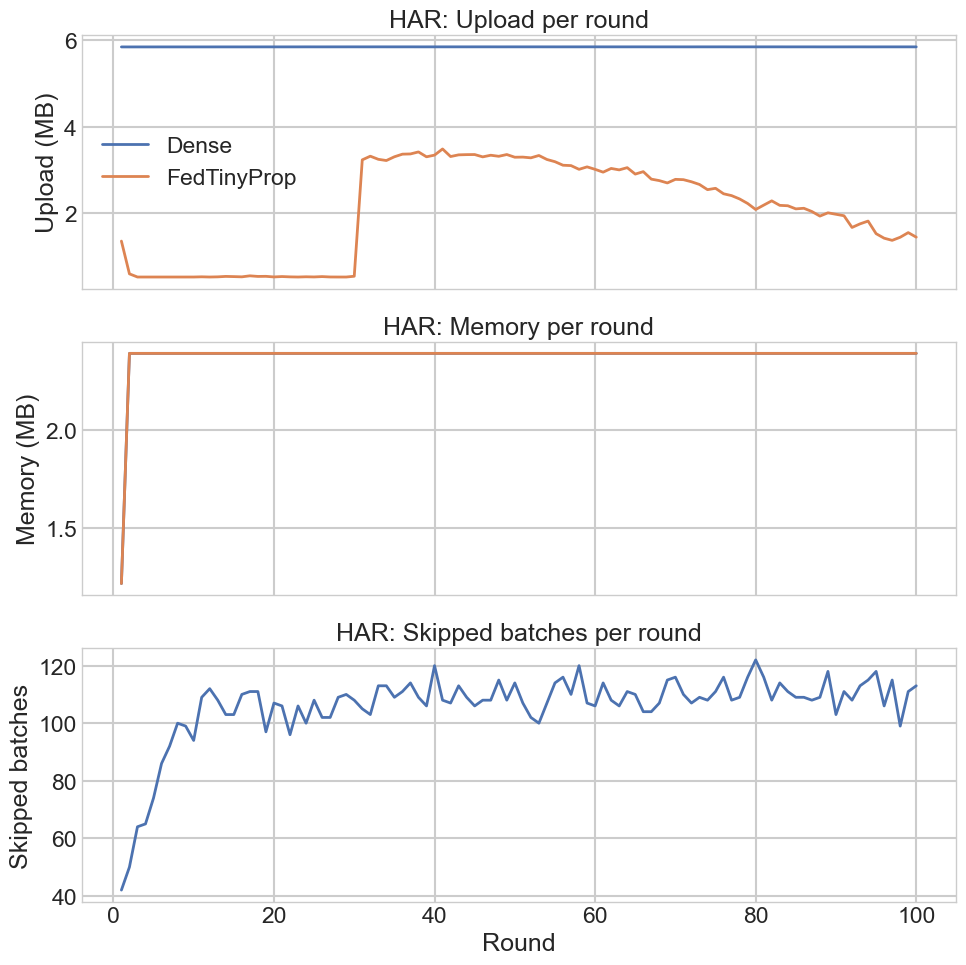

In [43]:
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

# Ensure round is numeric
df_dense["round"] = pd.to_numeric(df_dense["round"], errors="coerce")
df_ftp["round"]   = pd.to_numeric(df_ftp["round"], errors="coerce")

fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

# Upload per round
axes[0].plot(df_dense["round"], bytes_to_mb(df_dense["upload_bytes"]), label="Dense", linewidth=2)
axes[0].plot(df_ftp["round"],   bytes_to_mb(df_ftp["upload_bytes"]),   label="FedTinyProp", linewidth=2)
axes[0].set_ylabel("Upload (MB)")
axes[0].set_title("HAR: Upload per round")
axes[0].legend()

# Memory per round
axes[1].plot(df_dense["round"], df_dense["memory"], label="Dense", linewidth=2)
axes[1].plot(df_ftp["round"],   df_ftp["memory"],   label="FedTinyProp", linewidth=2)
axes[1].set_ylabel("Memory (MB)")
axes[1].set_title("HAR: Memory per round")

# Skipped batches per round (FedTinyProp only)
axes[2].plot(df_ftp["round"], df_ftp["skipped_batches"], label="FedTinyProp", linewidth=2)
axes[2].set_ylabel("Skipped batches")
axes[2].set_xlabel("Round")
axes[2].set_title("HAR: Skipped batches per round")

plt.tight_layout()
plt.show()